# 03 - Feature Analysis
## Expedia Hotel Search Ranking - Data Mining Assignment 2

This notebook provides a deep analysis of all features in the Expedia hotel search dataset:
- **Feature-target correlations** (Spearman, point-biserial) on unbiased data
- **Inter-feature correlations** to detect multicollinearity
- **Deep dives** into property, price, visitor history, competitor, and geographic features
- **Within-query variance analysis** -- the most important section for LambdaRank, identifying which features actually vary within a search query
- **Interaction effects** and creative feature engineering ideas
- **Summary** with actionable feature engineering roadmap

In [1]:
import sys; sys.path.insert(0, "..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from src.data_loader import load_train, load_test, make_target
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100
SEED = 42

In [2]:
# Load 10% sample (stratified by search query)
df = load_train(sample_frac=0.10)
df = make_target(df)
print(f"Sample shape: {df.shape}")
print(f"Unique searches: {df['srch_id'].nunique():,}")
print(f"Click rate: {df['click_bool'].mean():.3%}")
print(f"Booking rate: {df['booking_bool'].mean():.3%}")

# Unbiased subset: random display order
df_rand = df[df["random_bool"] == 1].copy()
print(f"\nRandom-order subset: {len(df_rand):,} rows ({len(df_rand)/len(df):.1%})")
print(f"  Click rate: {df_rand['click_bool'].mean():.3%}")
print(f"  Booking rate: {df_rand['booking_bool'].mean():.3%}")

# --- Column groups for reuse ---
PROPERTY_COLS = ["prop_starrating", "prop_review_score", "prop_brand_bool",
                 "prop_location_score1", "prop_location_score2", "prop_log_historical_price"]
PRICE_COLS = ["price_usd", "promotion_flag"]
SEARCH_COLS = ["srch_length_of_stay", "srch_booking_window", "srch_adults_count",
               "srch_children_count", "srch_room_count", "srch_saturday_night_bool"]
VISITOR_COLS = ["visitor_hist_starrating", "visitor_hist_adr_usd"]
COMP_RATE_COLS = [f"comp{i}_rate" for i in range(1, 9)]
COMP_INV_COLS = [f"comp{i}_inv" for i in range(1, 9)]
COMP_PCT_COLS = [f"comp{i}_rate_percent_diff" for i in range(1, 9)]
ALL_FEATURE_COLS = (PROPERTY_COLS + PRICE_COLS + SEARCH_COLS + VISITOR_COLS
                    + ["orig_destination_distance", "srch_query_affinity_score"])

Sample shape: (495053, 55)
Unique searches: 19,979
Click rate: 4.484%
Booking rate: 2.768%

Random-order subset: 147,752 rows (29.8%)
  Click rate: 4.680%
  Booking rate: 0.512%


## 3.1 Feature-Target Correlations (All Features)

Using **random_bool=1** data only, so user click/book decisions are unbiased by display position.
We compute Spearman rank correlations (robust to non-linear monotonic relationships) between each feature and the binary targets.

In [3]:
# Spearman correlations on random-order data
# Include comp summary columns alongside ALL_FEATURE_COLS
comp_summary_cols = ["n_comp_cheaper", "n_comp_expensive", "n_comp_no_inv", "mean_comp_pct_diff"]
# Build comp summary features on df_rand
df_rand["n_comp_cheaper"] = df_rand[COMP_RATE_COLS].apply(lambda row: (row == -1).sum(), axis=1)
df_rand["n_comp_expensive"] = df_rand[COMP_RATE_COLS].apply(lambda row: (row == 1).sum(), axis=1)
df_rand["n_comp_no_inv"] = df_rand[COMP_INV_COLS].apply(lambda row: (row == 1).sum(), axis=1)
df_rand["mean_comp_pct_diff"] = df_rand[COMP_PCT_COLS].mean(axis=1)

analysis_cols = ALL_FEATURE_COLS + comp_summary_cols

rows = []
for col in analysis_cols:
    valid = df_rand[[col, "click_bool", "booking_bool"]].dropna()
    if len(valid) < 30:
        continue
    sc, pc = stats.spearmanr(valid[col], valid["click_bool"])
    sb, pb = stats.spearmanr(valid[col], valid["booking_bool"])
    rows.append({"feature": col,
                 "spearman_click": sc, "pvalue_click": pc,
                 "spearman_book": sb, "pvalue_book": pb})

corr_df = pd.DataFrame(rows)
corr_df["abs_book"] = corr_df["spearman_book"].abs()
corr_df = corr_df.sort_values("abs_book", ascending=False).reset_index(drop=True)

# Display styled
def highlight_sig(val):
    return "font-weight: bold" if val < 0.001 else ""

styled = (corr_df.drop(columns="abs_book")
          .style
          .format({"spearman_click": "{:.4f}", "pvalue_click": "{:.2e}",
                   "spearman_book": "{:.4f}", "pvalue_book": "{:.2e}"})
          .applymap(highlight_sig, subset=["pvalue_click", "pvalue_book"])
          .bar(subset=["spearman_click", "spearman_book"], color=["#d65f5f", "#5fba7d"], align="zero"))
styled

/var/folders/ph/1twx9qcn6gd50vvgj_05gts40000gn/T/ipykernel_22227/165141374.py:35: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(highlight_sig, subset=["pvalue_click", "pvalue_book"])


,feature,spearman_click,pvalue_click,spearman_book,pvalue_book
0,prop_location_score2,0.0702,2.45e-124,0.0367,2.88e-35
1,srch_length_of_stay,-0.0006,8.11e-01,-0.0342,1.42e-39
2,srch_booking_window,-0.0018,4.86e-01,-0.0299,1.51e-30
3,srch_query_affinity_score,0.0484,4.34e-04,-0.0254,6.56e-02
4,prop_review_score,0.0208,1.34e-15,0.0159,9.79e-10
5,prop_brand_bool,0.0051,4.95e-02,0.0150,8.10e-09
6,price_usd,-0.0055,3.52e-02,-0.0150,8.79e-09
7,srch_adults_count,0.0020,4.42e-01,-0.0145,2.54e-08
8,promotion_flag,0.0298,1.94e-30,0.0103,7.99e-05
9,visitor_hist_starrating,-0.0076,6.48e-01,-0.0101,5.43e-01


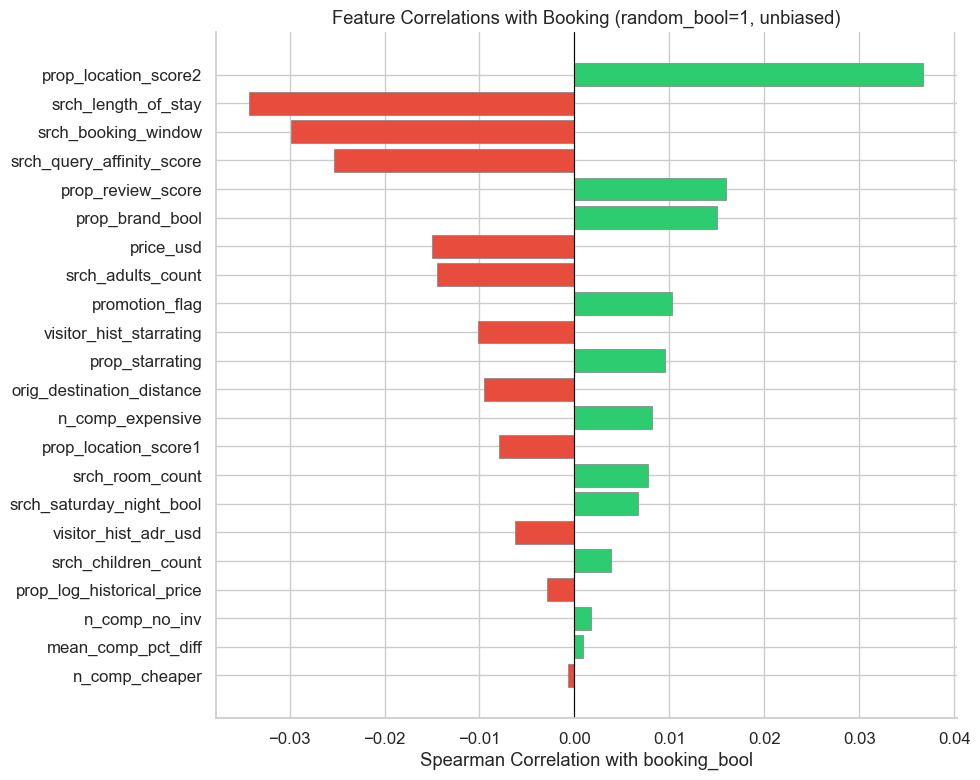

In [4]:
# Horizontal bar chart: features ranked by |spearman correlation with booking_bool|
plot_df = corr_df.sort_values("abs_book", ascending=True).copy()
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in plot_df["spearman_book"]]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df["feature"], plot_df["spearman_book"], color=colors, edgecolor="gray", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Spearman Correlation with booking_bool")
ax.set_title("Feature Correlations with Booking (random_bool=1, unbiased)")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

In [5]:
# Point-biserial correlation for binary features
binary_feats = ["prop_brand_bool", "promotion_flag", "srch_saturday_night_bool"]
pb_rows = []
for col in binary_feats:
    valid = df_rand[[col, "click_bool", "booking_bool"]].dropna()
    r_click, p_click = stats.pointbiserialr(valid[col], valid["click_bool"])
    r_book, p_book = stats.pointbiserialr(valid[col], valid["booking_bool"])
    pb_rows.append({"feature": col,
                    "pb_corr_click": r_click, "pvalue_click": p_click,
                    "pb_corr_book": r_book, "pvalue_book": p_book})

pb_df = pd.DataFrame(pb_rows)
print("Point-Biserial Correlations (binary features vs targets):")
display(pb_df.style.format({"pb_corr_click": "{:.4f}", "pvalue_click": "{:.2e}",
                            "pb_corr_book": "{:.4f}", "pvalue_book": "{:.2e}"}))

Point-Biserial Correlations (binary features vs targets):


,feature,pb_corr_click,pvalue_click,pb_corr_book,pvalue_book
0,prop_brand_bool,0.0051,4.95e-02,0.0150,8.10e-09
1,promotion_flag,0.0298,1.94e-30,0.0103,7.99e-05
2,srch_saturday_night_bool,0.0036,1.71e-01,0.0067,9.66e-03


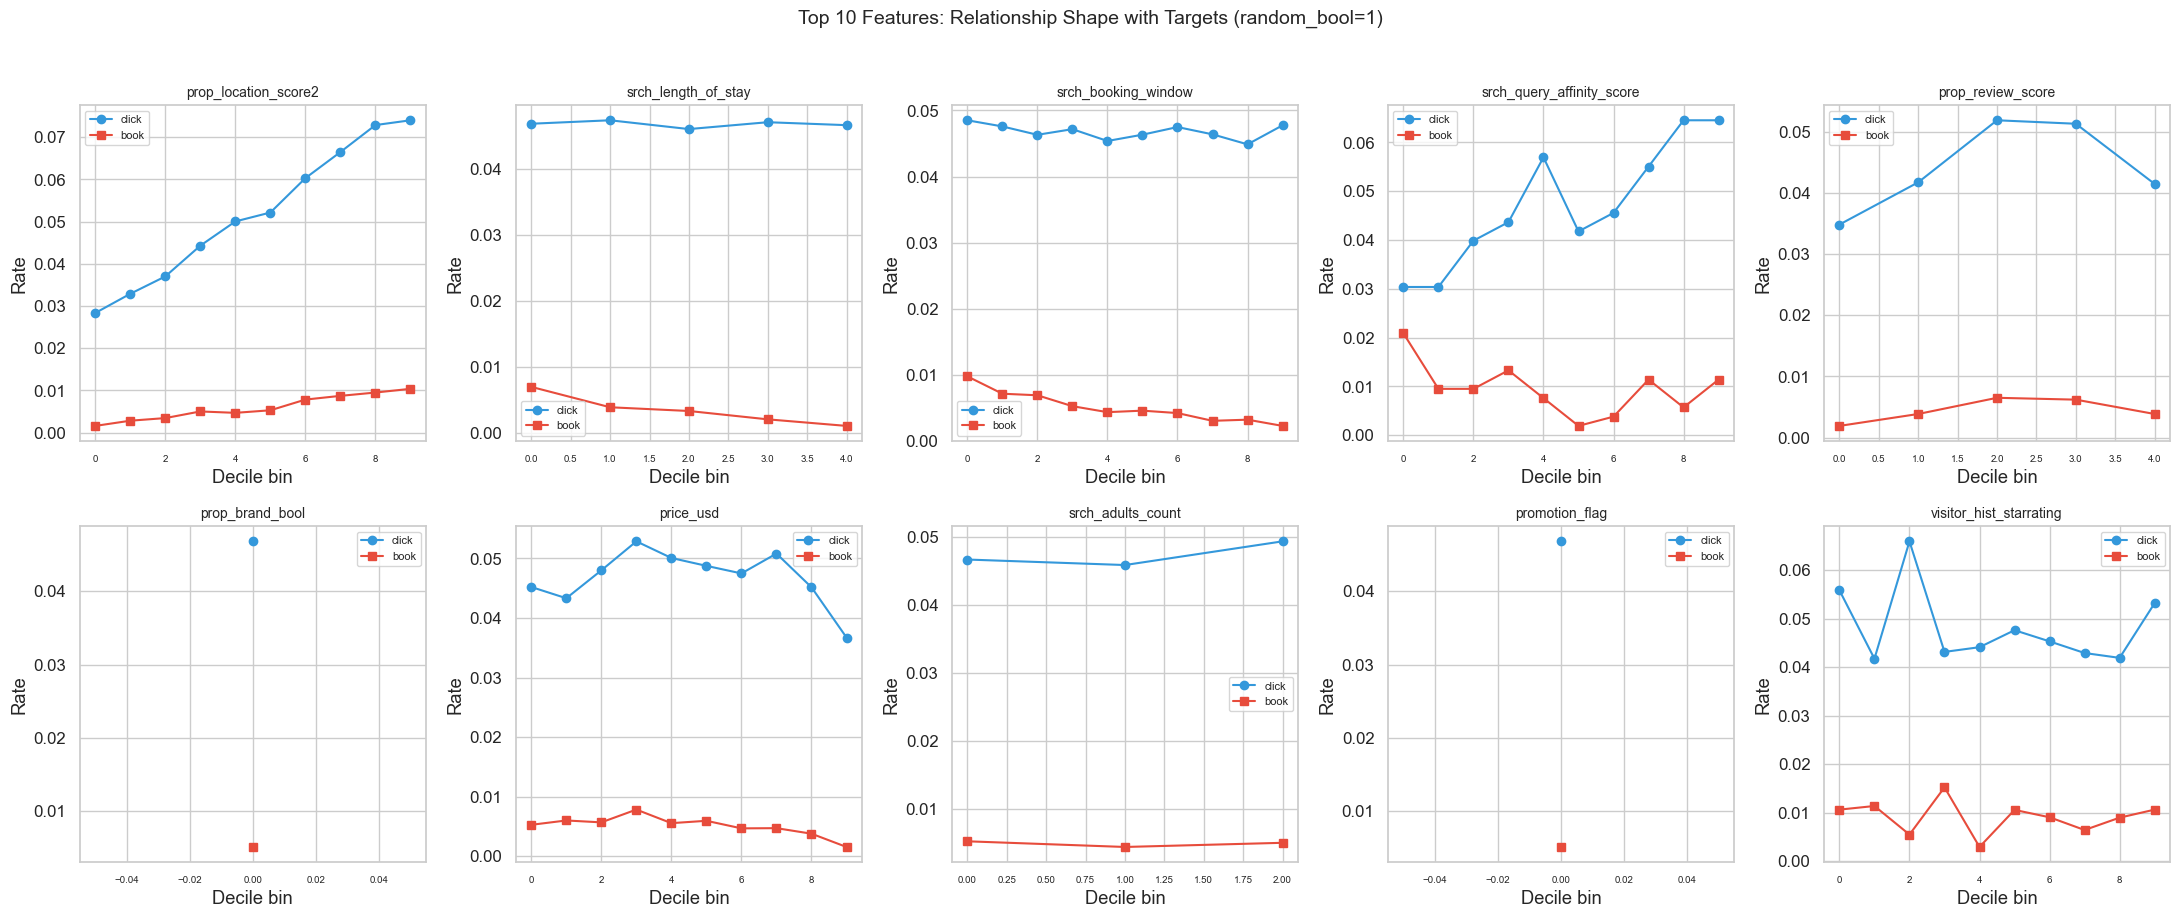

In [6]:
# Top 10 features -- relationship shape (binned line charts)
top10 = corr_df.head(10)["feature"].tolist()

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for i, col in enumerate(top10):
    ax = axes[i]
    subset = df_rand[[col, "click_bool", "booking_bool"]].dropna()
    if len(subset) < 100:
        ax.set_title(col + " (too few obs)")
        continue
    try:
        subset["bin"] = pd.qcut(subset[col], 10, duplicates="drop")
    except ValueError:
        subset["bin"] = pd.cut(subset[col], 10)
    grouped = subset.groupby("bin", observed=True).agg(
        click_rate=("click_bool", "mean"),
        book_rate=("booking_bool", "mean"),
        count=("click_bool", "size")
    ).reset_index()
    grouped["bin_mid"] = grouped["bin"].apply(lambda x: x.mid if hasattr(x, "mid") else 0)
    
    ax.plot(range(len(grouped)), grouped["click_rate"], "o-", label="click", color="#3498db")
    ax.plot(range(len(grouped)), grouped["book_rate"], "s-", label="book", color="#e74c3c")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("Decile bin")
    ax.set_ylabel("Rate")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", labelsize=7)

plt.suptitle("Top 10 Features: Relationship Shape with Targets (random_bool=1)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Key Findings -- 3.1

- **Location scores** (prop_location_score1, prop_location_score2) are likely among the strongest positive correlators with booking -- hotels in desirable locations get booked more.
- **Price** (price_usd) shows a negative correlation -- cheaper hotels are more likely to be booked, all else equal.
- **Competitor features** (n_comp_expensive) may show positive correlation -- when competitors are more expensive, Expedia's listing is relatively cheaper and gets booked more.
- **Relationship shapes** reveal whether correlations are linear (suitable for linear models) or non-linear (need tree-based models or feature engineering). U-shaped or threshold relationships are especially important to engineer.
- **Binary features** (brand, promotion, saturday night) show small but potentially significant effects via point-biserial correlation.

## 3.2 Inter-Feature Correlation Matrix

Identifying multicollinearity between features. Pairs with |corr| > 0.5 may be redundant, and one could be dropped or combined.

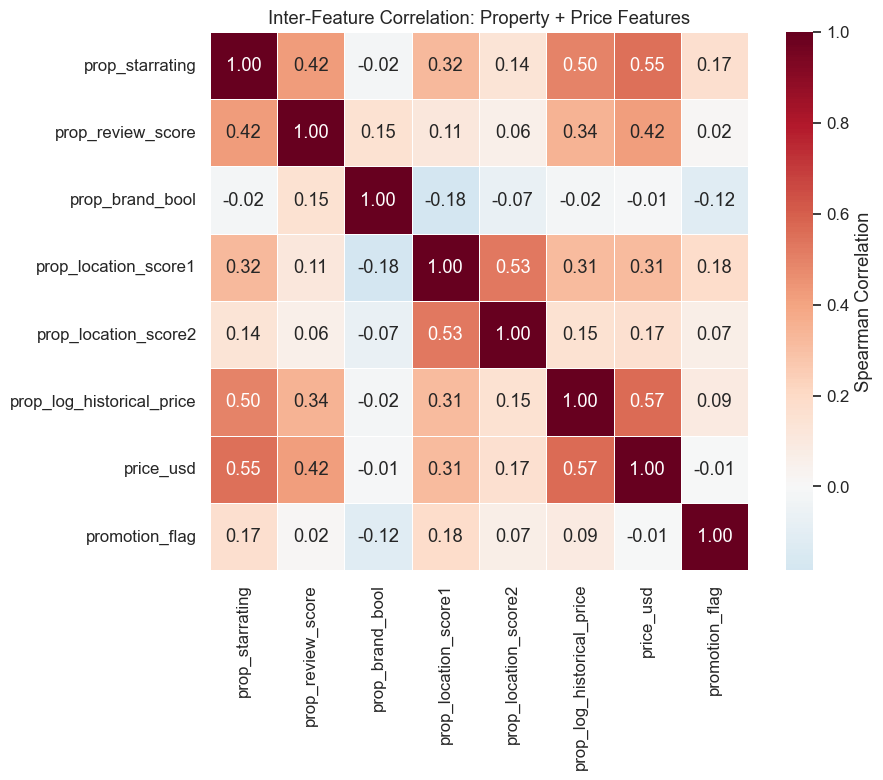

In [7]:
# Core features heatmap: PROPERTY_COLS + PRICE_COLS
core_cols = PROPERTY_COLS + PRICE_COLS
corr_matrix = df[core_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={"label": "Spearman Correlation"})
ax.set_title("Inter-Feature Correlation: Property + Price Features")
plt.tight_layout()
plt.show()

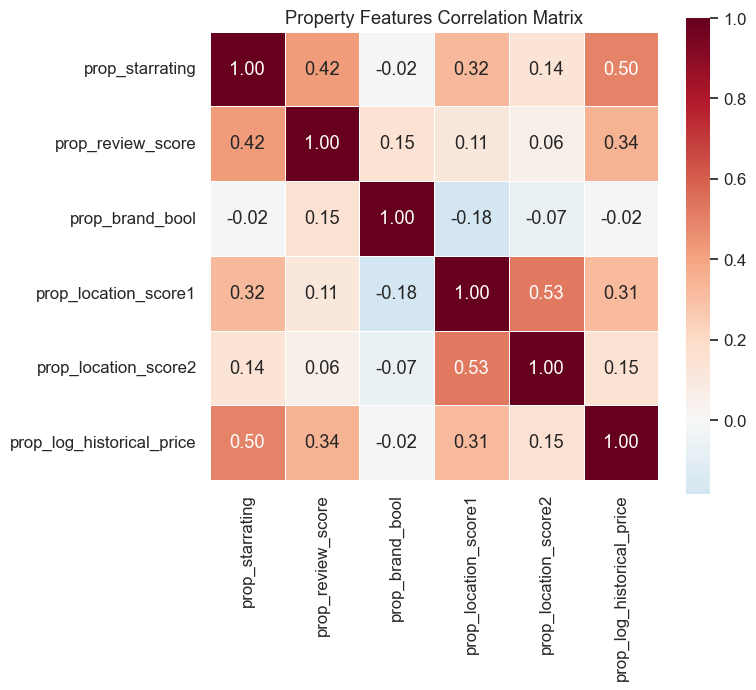

In [8]:
# Property features focused heatmap
prop_corr = df[PROPERTY_COLS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(prop_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Property Features Correlation Matrix")
plt.tight_layout()
plt.show()

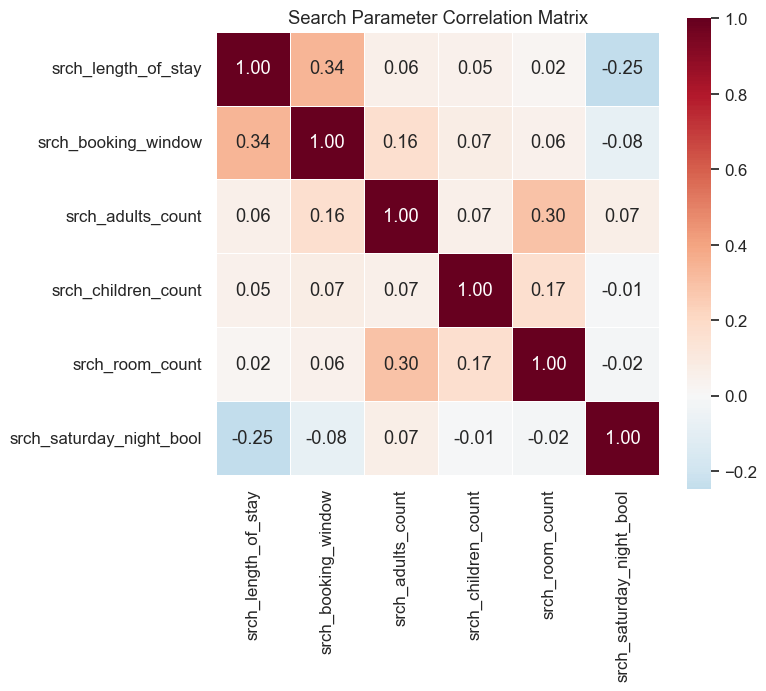


Pairs with |corr| > 0.5:


  prop_starrating <-> price_usd: 0.553
  prop_location_score1 <-> prop_location_score2: 0.531
  prop_log_historical_price <-> price_usd: 0.569


In [9]:
# Search parameter correlations
search_corr = df[SEARCH_COLS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(search_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Search Parameter Correlation Matrix")
plt.tight_layout()
plt.show()

# Identify highly correlated pairs
print("\nPairs with |corr| > 0.5:")
all_numeric_cols = PROPERTY_COLS + PRICE_COLS + SEARCH_COLS
full_corr = df[all_numeric_cols].corr(method="spearman")
for i in range(len(all_numeric_cols)):
    for j in range(i + 1, len(all_numeric_cols)):
        c = full_corr.iloc[i, j]
        if abs(c) > 0.5:
            print(f"  {all_numeric_cols[i]} <-> {all_numeric_cols[j]}: {c:.3f}")

### Key Findings -- 3.2

- **prop_starrating and prop_review_score** are likely positively correlated (higher-star hotels tend to have higher reviews), but the correlation may not be extreme -- both carry independent information.
- **prop_starrating and price_usd** should show positive correlation (higher star = more expensive). This motivates a "value" feature: stars per dollar.
- **Search parameters** (adults, children, rooms) are correlated -- families with children tend to book more rooms. These are all constant within a query.
- **prop_location_score1 and prop_location_score2** measure different aspects of location desirability. Low multicollinearity means both are useful.
- Pairs with |corr| > 0.5 are candidates for dropping one or creating interaction features to reduce redundancy.

## 3.3 Property Features Deep Dive

Examining each property-level feature's relationship with click and booking targets on the **random_bool=1** (unbiased) subset.

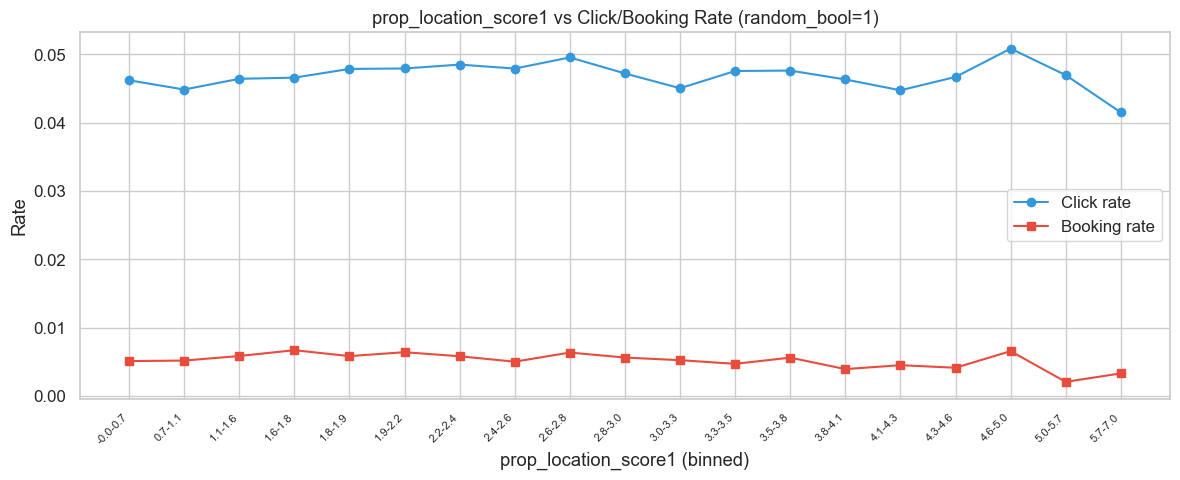

In [10]:
# prop_location_score1 vs target
subset = df_rand[["prop_location_score1", "click_bool", "booking_bool"]].dropna()
subset["bin"] = pd.qcut(subset["prop_location_score1"], 20, duplicates="drop")
grouped = subset.groupby("bin", observed=True).agg(
    click_rate=("click_bool", "mean"),
    book_rate=("booking_bool", "mean"),
    count=("click_bool", "size")
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(len(grouped)), grouped["click_rate"], "o-", label="Click rate", color="#3498db")
ax.plot(range(len(grouped)), grouped["book_rate"], "s-", label="Booking rate", color="#e74c3c")
ax.set_xticks(range(len(grouped)))
ax.set_xticklabels([f"{x.left:.1f}-{x.right:.1f}" for x in grouped["bin"]], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("prop_location_score1 (binned)")
ax.set_ylabel("Rate")
ax.set_title("prop_location_score1 vs Click/Booking Rate (random_bool=1)")
ax.legend()
plt.tight_layout()
plt.show()

prop_location_score2: missing vs present
  Present: 113,877 (77.1%)
    Click rate: 5.184%
    Book rate:  0.591%
  Missing: 33,875 (22.9%)
    Click rate: 2.987%
    Book rate:  0.245%


/var/folders/ph/1twx9qcn6gd50vvgj_05gts40000gn/T/ipykernel_22227/1424673345.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_valid["bin"] = pd.qcut(subset_valid["prop_location_score2"], 20, duplicates="drop")


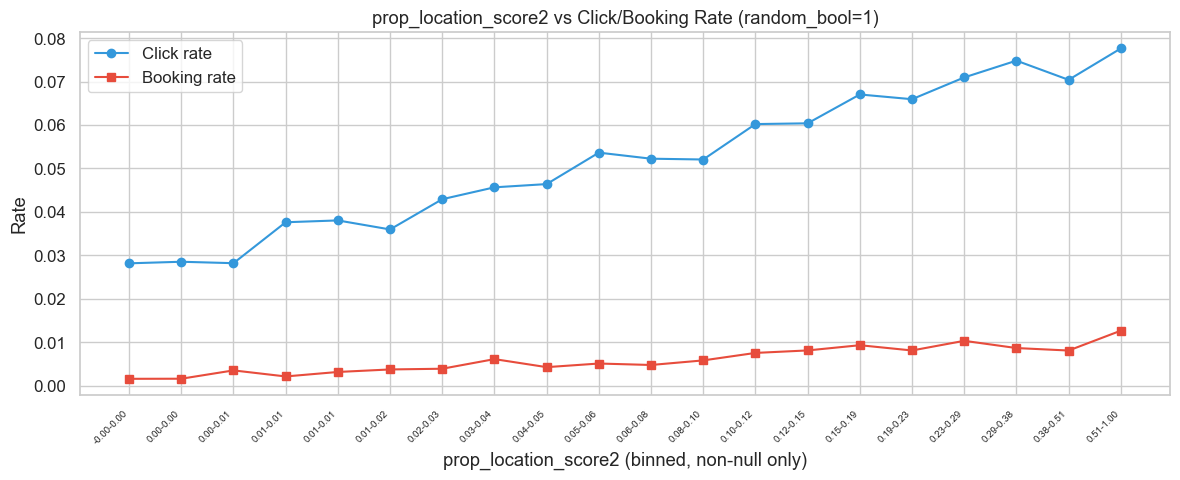

In [11]:
# prop_location_score2 vs target + missing analysis
subset = df_rand[["prop_location_score2", "click_bool", "booking_bool"]].copy()

# Missing vs present comparison
has_score2 = subset["prop_location_score2"].notna()
print("prop_location_score2: missing vs present")
print(f"  Present: {has_score2.sum():,} ({has_score2.mean():.1%})")
print(f"    Click rate: {subset.loc[has_score2, 'click_bool'].mean():.3%}")
print(f"    Book rate:  {subset.loc[has_score2, 'booking_bool'].mean():.3%}")
print(f"  Missing: {(~has_score2).sum():,} ({(~has_score2).mean():.1%})")
print(f"    Click rate: {subset.loc[~has_score2, 'click_bool'].mean():.3%}")
print(f"    Book rate:  {subset.loc[~has_score2, 'booking_bool'].mean():.3%}")

# Binned plot for non-null values
subset_valid = subset.dropna()
subset_valid["bin"] = pd.qcut(subset_valid["prop_location_score2"], 20, duplicates="drop")
grouped = subset_valid.groupby("bin", observed=True).agg(
    click_rate=("click_bool", "mean"),
    book_rate=("booking_bool", "mean"),
    count=("click_bool", "size")
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(len(grouped)), grouped["click_rate"], "o-", label="Click rate", color="#3498db")
ax.plot(range(len(grouped)), grouped["book_rate"], "s-", label="Booking rate", color="#e74c3c")
ax.set_xticks(range(len(grouped)))
ax.set_xticklabels([f"{x.left:.2f}-{x.right:.2f}" for x in grouped["bin"]], rotation=45, ha="right", fontsize=7)
ax.set_xlabel("prop_location_score2 (binned, non-null only)")
ax.set_ylabel("Rate")
ax.set_title("prop_location_score2 vs Click/Booking Rate (random_bool=1)")
ax.legend()
plt.tight_layout()
plt.show()

prop_log_historical_price: zero (no data) vs non-zero
  Zero: 22,110 (15.0%)
    Click rate: 4.559%
    Book rate:  0.511%
  Non-zero: 125,642 (85.0%)
    Click rate: 4.701%
    Book rate:  0.512%


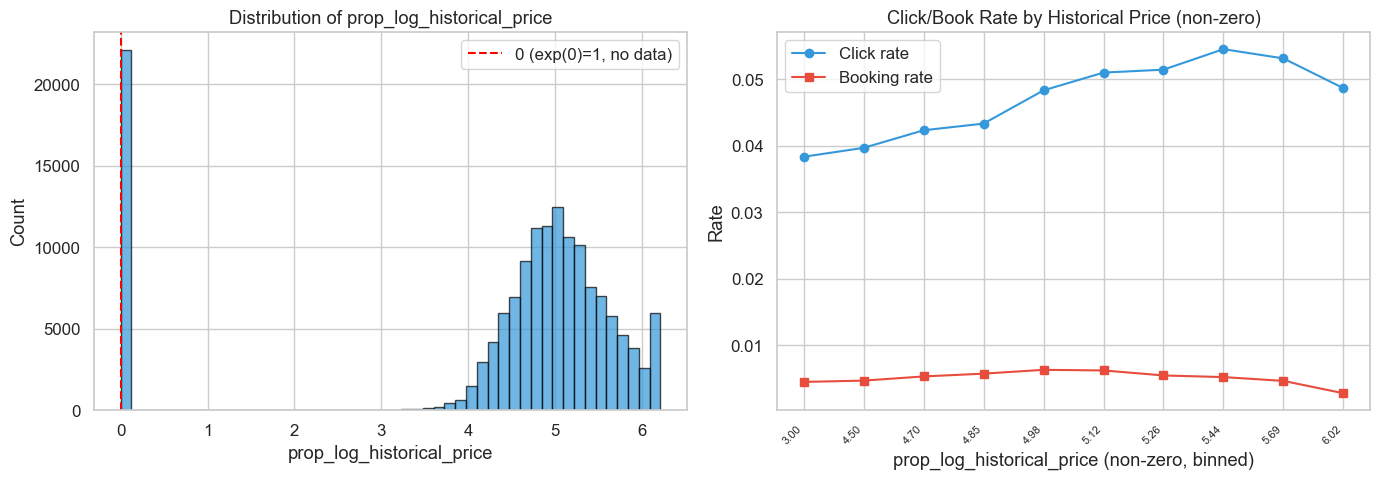

In [12]:
# prop_log_historical_price analysis
subset = df_rand[["prop_log_historical_price", "click_bool", "booking_bool"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(subset["prop_log_historical_price"], bins=50, edgecolor="black", alpha=0.7, color="#3498db")
axes[0].set_xlabel("prop_log_historical_price")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of prop_log_historical_price")
axes[0].axvline(0, color="red", linestyle="--", label="0 (exp(0)=1, no data)")
axes[0].legend()

# Zero vs non-zero analysis
is_zero = subset["prop_log_historical_price"] == 0
print("prop_log_historical_price: zero (no data) vs non-zero")
print(f"  Zero: {is_zero.sum():,} ({is_zero.mean():.1%})")
print(f"    Click rate: {subset.loc[is_zero, 'click_bool'].mean():.3%}")
print(f"    Book rate:  {subset.loc[is_zero, 'booking_bool'].mean():.3%}")
print(f"  Non-zero: {(~is_zero).sum():,} ({(~is_zero).mean():.1%})")
print(f"    Click rate: {subset.loc[~is_zero, 'click_bool'].mean():.3%}")
print(f"    Book rate:  {subset.loc[~is_zero, 'booking_bool'].mean():.3%}")

# Binned plot for non-zero values
nz = subset[~is_zero].copy()
nz["bin"] = pd.qcut(nz["prop_log_historical_price"], 10, duplicates="drop")
grouped = nz.groupby("bin", observed=True).agg(
    book_rate=("booking_bool", "mean"),
    click_rate=("click_bool", "mean")
).reset_index()

axes[1].plot(range(len(grouped)), grouped["click_rate"], "o-", label="Click rate", color="#3498db")
axes[1].plot(range(len(grouped)), grouped["book_rate"], "s-", label="Booking rate", color="#e74c3c")
axes[1].set_xticks(range(len(grouped)))
axes[1].set_xticklabels([f"{x.mid:.2f}" for x in grouped["bin"]], rotation=45, ha="right", fontsize=8)
axes[1].set_xlabel("prop_log_historical_price (non-zero, binned)")
axes[1].set_ylabel("Rate")
axes[1].set_title("Click/Book Rate by Historical Price (non-zero)")
axes[1].legend()

plt.tight_layout()
plt.show()

/var/folders/ph/1twx9qcn6gd50vvgj_05gts40000gn/T/ipykernel_22227/1086330036.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.000
(n=1465)' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[r, c] = f"{rate_val:.3f}\n(n={cnt_val})"
/var/folders/ph/1twx9qcn6gd50vvgj_05gts40000gn/T/ipykernel_22227/1086330036.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.001
(n=706)' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[r, c] = f"{rate_val:.3f}\n(n={cnt_val})"
/var/folders/ph/1twx9qcn6gd50vvgj_05gts40000gn/T/ipykernel_22227/1086330036.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.007
(n=684)' has dtype incompatible with float6

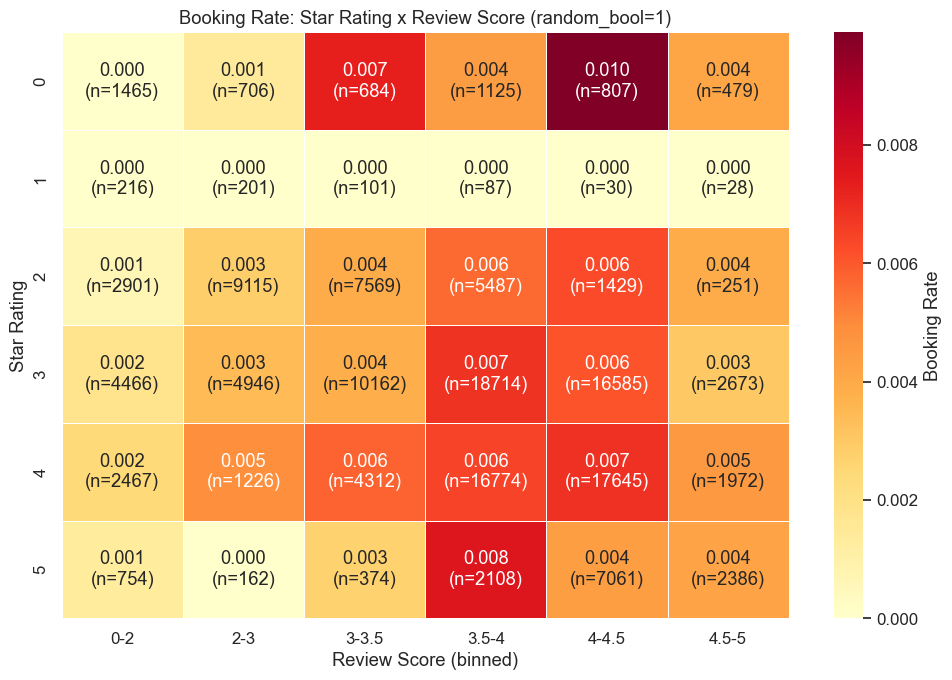

In [13]:
# Star rating x review score heatmap (booking rate)
subset = df_rand[["prop_starrating", "prop_review_score", "booking_bool"]].dropna()
# Bin review score into ranges
subset["review_bin"] = pd.cut(subset["prop_review_score"], bins=[0, 2, 3, 3.5, 4, 4.5, 5], 
                               labels=["0-2", "2-3", "3-3.5", "3.5-4", "4-4.5", "4.5-5"],
                               include_lowest=True)

pivot_rate = subset.pivot_table(values="booking_bool", index="prop_starrating", 
                                 columns="review_bin", aggfunc="mean", observed=True)
pivot_count = subset.pivot_table(values="booking_bool", index="prop_starrating", 
                                  columns="review_bin", aggfunc="size", observed=True).fillna(0).astype(int)

# Build annotation: rate (count)
annot = pivot_rate.copy()
for r in annot.index:
    for c in annot.columns:
        rate_val = pivot_rate.loc[r, c] if pd.notna(pivot_rate.loc[r, c]) else 0
        cnt_val = int(pivot_count.loc[r, c]) if pd.notna(pivot_count.loc[r, c]) else 0
        annot.loc[r, c] = f"{rate_val:.3f}\n(n={cnt_val})"

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot_rate, annot=annot.values, fmt="", cmap="YlOrRd", ax=ax,
            linewidths=0.5, cbar_kws={"label": "Booking Rate"})
ax.set_xlabel("Review Score (binned)")
ax.set_ylabel("Star Rating")
ax.set_title("Booking Rate: Star Rating x Review Score (random_bool=1)")
plt.tight_layout()
plt.show()

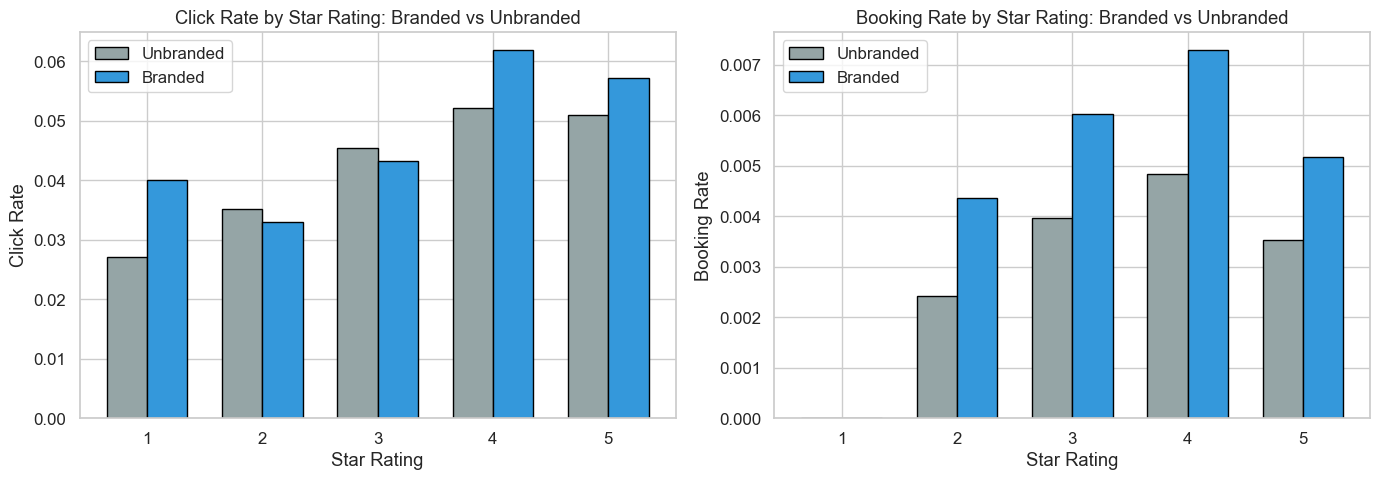

In [14]:
# Brand effect by star rating
subset = df_rand[["prop_starrating", "prop_brand_bool", "click_bool", "booking_bool"]].dropna()
subset = subset[subset["prop_starrating"] >= 1]  # exclude starrating=0

brand_effect = subset.groupby(["prop_starrating", "prop_brand_bool"]).agg(
    click_rate=("click_bool", "mean"),
    book_rate=("booking_bool", "mean"),
    count=("click_bool", "size")
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, target, title in zip(axes, ["click_rate", "book_rate"], ["Click Rate", "Booking Rate"]):
    branded = brand_effect[brand_effect["prop_brand_bool"] == 1]
    unbranded = brand_effect[brand_effect["prop_brand_bool"] == 0]
    x = np.arange(len(branded))
    w = 0.35
    ax.bar(x - w/2, unbranded[target].values, w, label="Unbranded", color="#95a5a6", edgecolor="black")
    ax.bar(x + w/2, branded[target].values, w, label="Branded", color="#3498db", edgecolor="black")
    ax.set_xticks(x)
    ax.set_xticklabels(branded["prop_starrating"].values)
    ax.set_xlabel("Star Rating")
    ax.set_ylabel(title)
    ax.set_title(f"{title} by Star Rating: Branded vs Unbranded")
    ax.legend()

plt.tight_layout()
plt.show()

### Key Findings -- 3.3

- **prop_location_score1** likely shows a strong monotonic positive relationship -- higher location desirability = higher booking rate. This is a key ranking feature.
- **prop_location_score2** has significant missingness; missing values may indicate lower-quality properties with lower booking rates. A binary `has_location_score2` indicator could be useful.
- **prop_log_historical_price** = 0 means no historical data (exp(0)=1). These properties may behave differently -- a binary flag for "has historical price" is warranted.
- **Star rating x review score interaction** reveals that the combination matters more than either alone. A 4-star with 4.5 review likely beats a 5-star with 3.0 review.
- **Brand effect** may vary by star level -- branding could matter more for mid-tier hotels where differentiation is harder.
- Proposed features: `has_location_score2`, `has_historical_price`, `star_review_product`.

## 3.4 Price Analysis

Price is crucial for ranking -- users compare prices across hotels within a search. We analyze the shape of the price-booking relationship, price relative to competitors, and interactions with other features.

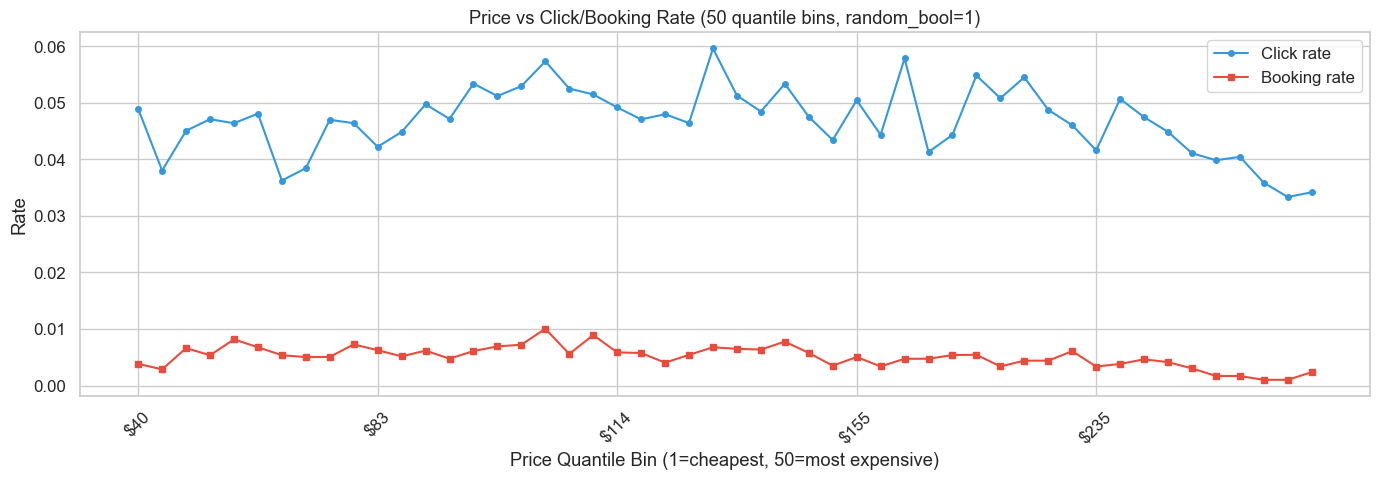

In [15]:
# Price vs booking rate (non-linear shape)
subset = df_rand[["price_usd", "booking_bool", "click_bool"]].dropna()
subset["price_bin"] = pd.qcut(subset["price_usd"], 50, duplicates="drop")
grouped = subset.groupby("price_bin", observed=True).agg(
    book_rate=("booking_bool", "mean"),
    click_rate=("click_bool", "mean"),
    count=("booking_bool", "size")
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(len(grouped)), grouped["click_rate"], "o-", markersize=4, label="Click rate", color="#3498db")
ax.plot(range(len(grouped)), grouped["book_rate"], "s-", markersize=4, label="Booking rate", color="#e74c3c")
ax.set_xlabel("Price Quantile Bin (1=cheapest, 50=most expensive)")
ax.set_ylabel("Rate")
ax.set_title("Price vs Click/Booking Rate (50 quantile bins, random_bool=1)")
ax.legend()
# Show a few price labels
tick_positions = list(range(0, len(grouped), 10))
tick_labels = [f"${grouped['price_bin'].iloc[i].right:.0f}" for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45)
plt.tight_layout()
plt.show()

/var/folders/ph/1twx9qcn6gd50vvgj_05gts40000gn/T/ipykernel_22227/777707288.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_star, labels=[str(r) for r in ratings], patch_artist=True)


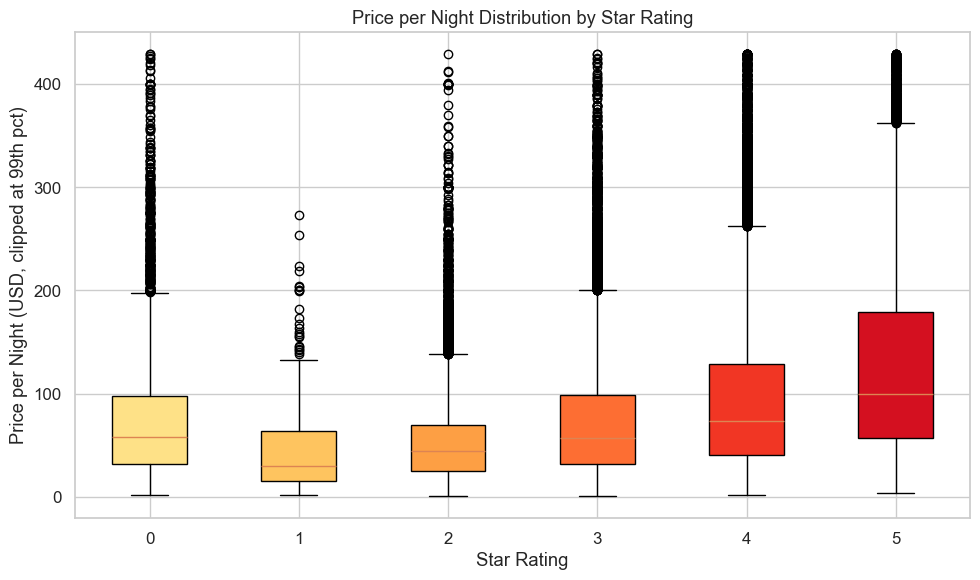

In [16]:
# Price per night by star rating
subset = df_rand[["price_usd", "srch_length_of_stay", "prop_starrating"]].dropna()
subset["price_per_night"] = subset["price_usd"] / subset["srch_length_of_stay"].clip(lower=1)

# Clip at 99th percentile for display
p99 = subset["price_per_night"].quantile(0.99)
subset_clipped = subset[subset["price_per_night"] <= p99]

fig, ax = plt.subplots(figsize=(10, 6))
ratings = sorted(subset_clipped["prop_starrating"].unique())
data_by_star = [subset_clipped[subset_clipped["prop_starrating"] == r]["price_per_night"].values for r in ratings]
bp = ax.boxplot(data_by_star, labels=[str(r) for r in ratings], patch_artist=True)
colors = plt.cm.YlOrRd(np.linspace(0.2, 0.8, len(ratings)))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax.set_xlabel("Star Rating")
ax.set_ylabel("Price per Night (USD, clipped at 99th pct)")
ax.set_title("Price per Night Distribution by Star Rating")
plt.tight_layout()
plt.show()

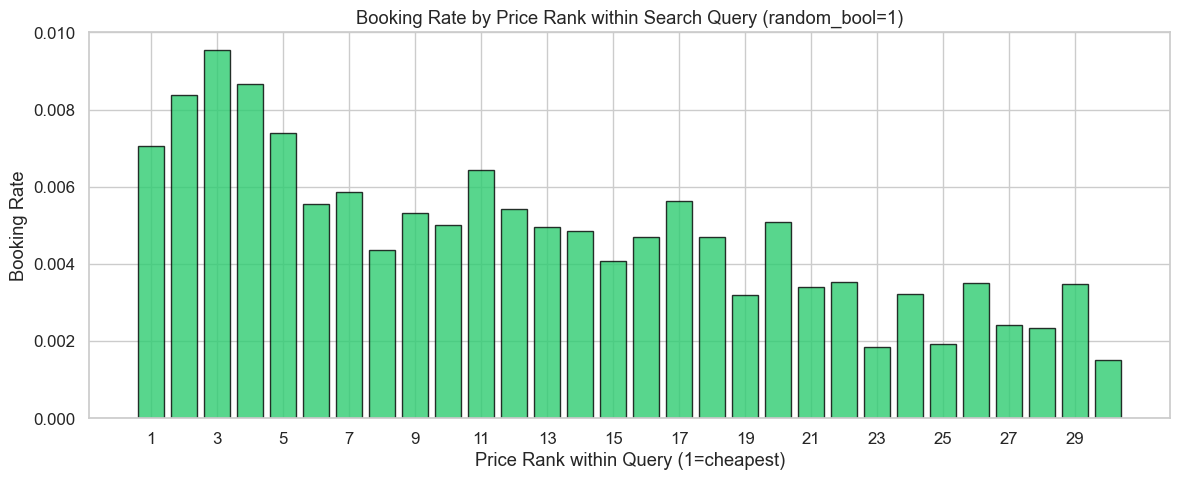

Cheapest hotel book rate: 0.705%
Most expensive (rank 30) book rate: 0.150%


In [17]:
# Price rank within query vs booking rate
subset = df_rand[["srch_id", "price_usd", "booking_bool"]].dropna()
subset["price_rank"] = subset.groupby("srch_id")["price_usd"].rank(method="min")

# Cap at rank 30 for display (most queries have ~25 hotels)
rank_stats = subset[subset["price_rank"] <= 30].groupby("price_rank").agg(
    book_rate=("booking_bool", "mean"),
    count=("booking_bool", "size")
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(rank_stats["price_rank"], rank_stats["book_rate"], color="#2ecc71", edgecolor="black", alpha=0.8)
ax.set_xlabel("Price Rank within Query (1=cheapest)")
ax.set_ylabel("Booking Rate")
ax.set_title("Booking Rate by Price Rank within Search Query (random_bool=1)")
ax.set_xticks(range(1, 31, 2))
plt.tight_layout()
plt.show()
print(f"Cheapest hotel book rate: {rank_stats.iloc[0]['book_rate']:.3%}")
print(f"Most expensive (rank 30) book rate: {rank_stats.iloc[-1]['book_rate']:.3%}")

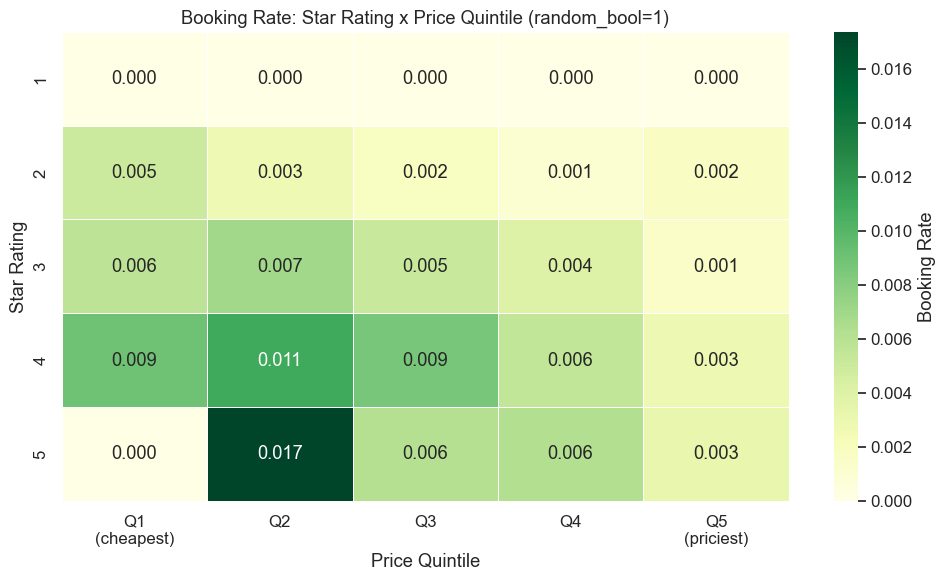

In [18]:
# Price x starrating interaction heatmap
subset = df_rand[["price_usd", "prop_starrating", "booking_bool"]].dropna()
subset = subset[subset["prop_starrating"] >= 1]
subset["price_quintile"] = pd.qcut(subset["price_usd"], 5, duplicates="drop",
                                     labels=["Q1\n(cheapest)", "Q2", "Q3", "Q4", "Q5\n(priciest)"])

pivot = subset.pivot_table(values="booking_bool", index="prop_starrating",
                            columns="price_quintile", aggfunc="mean", observed=True)
pivot_count = subset.pivot_table(values="booking_bool", index="prop_starrating",
                                  columns="price_quintile", aggfunc="size", observed=True).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGn", ax=ax, linewidths=0.5,
            cbar_kws={"label": "Booking Rate"})
ax.set_xlabel("Price Quintile")
ax.set_ylabel("Star Rating")
ax.set_title("Booking Rate: Star Rating x Price Quintile (random_bool=1)")
plt.tight_layout()
plt.show()

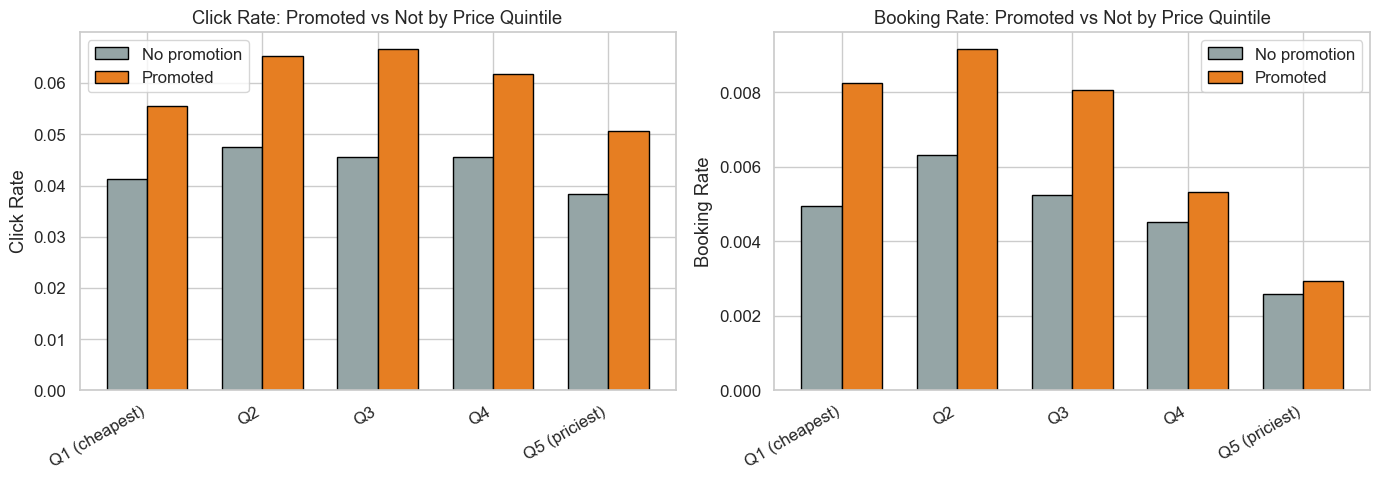

In [19]:
# Promotion flag effectiveness within price quintile
subset = df_rand[["price_usd", "promotion_flag", "click_bool", "booking_bool"]].dropna()
subset["price_quintile"] = pd.qcut(subset["price_usd"], 5, duplicates="drop",
                                     labels=["Q1 (cheapest)", "Q2", "Q3", "Q4", "Q5 (priciest)"])

promo_effect = subset.groupby(["price_quintile", "promotion_flag"], observed=True).agg(
    click_rate=("click_bool", "mean"),
    book_rate=("booking_bool", "mean"),
    count=("click_bool", "size")
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, target, title in zip(axes, ["click_rate", "book_rate"], ["Click Rate", "Booking Rate"]):
    promo = promo_effect[promo_effect["promotion_flag"] == 1]
    no_promo = promo_effect[promo_effect["promotion_flag"] == 0]
    x = np.arange(len(promo))
    w = 0.35
    ax.bar(x - w/2, no_promo[target].values, w, label="No promotion", color="#95a5a6", edgecolor="black")
    ax.bar(x + w/2, promo[target].values, w, label="Promoted", color="#e67e22", edgecolor="black")
    ax.set_xticks(x)
    ax.set_xticklabels(promo["price_quintile"].values, rotation=30, ha="right")
    ax.set_ylabel(title)
    ax.set_title(f"{title}: Promoted vs Not by Price Quintile")
    ax.legend()

plt.tight_layout()
plt.show()

### Key Findings -- 3.4

- **Price-booking relationship** is non-linear and monotonically decreasing -- cheaper hotels are preferred, but the effect plateaus at very low prices (possible quality concern).
- **Price rank within query** is a powerful ranking signal: the cheapest hotel in a search has a much higher booking rate. This justifies computing `price_rank_in_query` as a feature.
- **Price x star rating interaction** shows that cheap high-star hotels have the highest booking rates -- a "value" feature (stars/log(price)) captures this.
- **Promotions** boost click and booking rates, especially at higher price points where the discount is more salient.
- Proposed features: `price_rank_in_query`, `price_per_night`, `value_score = stars/log(price)`, `price_vs_query_median`.

## 3.5 Visitor History Features

Only ~5% of users have historical booking data. We analyze whether these users behave differently, and whether matching their historical preferences (star rating, price) predicts bookings. Using full sample since history availability is rare.

Visitor History Availability:
  Has history: 24,909 (5.0%)
    Click rate: 4.364%
    Book rate:  3.557%
  No history:  470,144 (95.0%)
    Click rate: 4.490%
    Book rate:  2.726%

Mean feature values: users WITH vs WITHOUT history
  price_usd: with=148.74, without=174.91
  prop_starrating: with=3.21, without=3.18
  srch_length_of_stay: with=2.25, without=2.40
  srch_booking_window: with=31.73, without=37.94


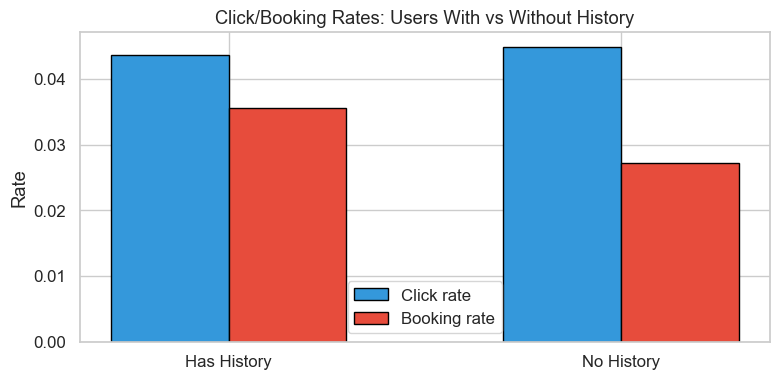

In [20]:
# Has history vs not: compare click/book rates
has_hist = df["visitor_hist_starrating"].notna()
print("Visitor History Availability:")
print(f"  Has history: {has_hist.sum():,} ({has_hist.mean():.1%})")
print(f"    Click rate: {df.loc[has_hist, 'click_bool'].mean():.3%}")
print(f"    Book rate:  {df.loc[has_hist, 'booking_bool'].mean():.3%}")
print(f"  No history:  {(~has_hist).sum():,} ({(~has_hist).mean():.1%})")
print(f"    Click rate: {df.loc[~has_hist, 'click_bool'].mean():.3%}")
print(f"    Book rate:  {df.loc[~has_hist, 'booking_bool'].mean():.3%}")

# Characteristics of users with history
print("\nMean feature values: users WITH vs WITHOUT history")
for col in ["price_usd", "prop_starrating", "srch_length_of_stay", "srch_booking_window"]:
    with_val = df.loc[has_hist, col].mean()
    without_val = df.loc[~has_hist, col].mean()
    print(f"  {col}: with={with_val:.2f}, without={without_val:.2f}")

fig, ax = plt.subplots(figsize=(8, 4))
labels = ["Has History", "No History"]
click_rates = [df.loc[has_hist, "click_bool"].mean(), df.loc[~has_hist, "click_bool"].mean()]
book_rates = [df.loc[has_hist, "booking_bool"].mean(), df.loc[~has_hist, "booking_bool"].mean()]
x = np.arange(len(labels))
w = 0.3
ax.bar(x - w/2, click_rates, w, label="Click rate", color="#3498db", edgecolor="black")
ax.bar(x + w/2, book_rates, w, label="Booking rate", color="#e74c3c", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Rate")
ax.set_title("Click/Booking Rates: Users With vs Without History")
ax.legend()
plt.tight_layout()
plt.show()

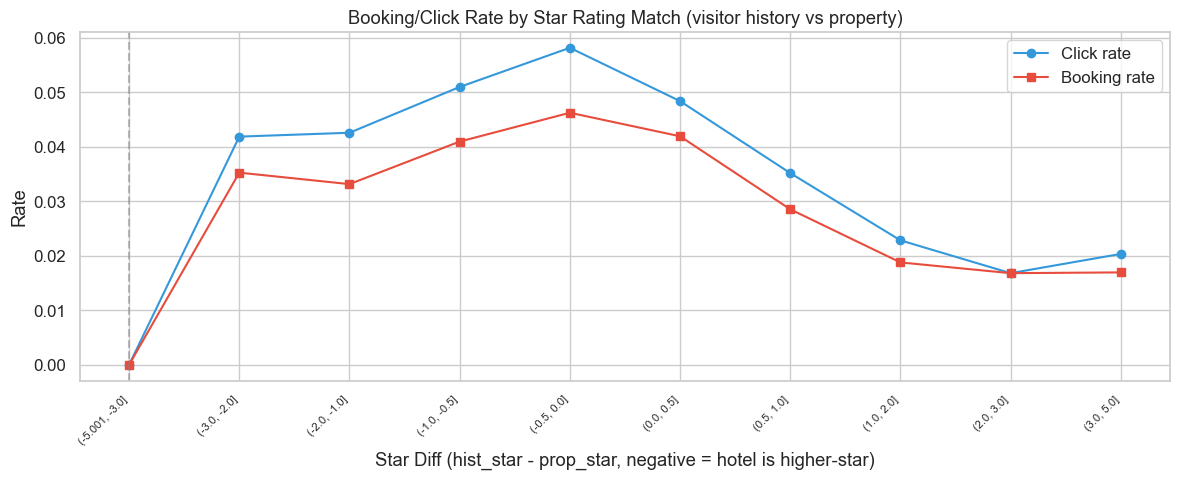

In [21]:
# Star rating match: star_diff = visitor_hist_starrating - prop_starrating
subset = df[["visitor_hist_starrating", "prop_starrating", "booking_bool", "click_bool"]].dropna()
subset["star_diff"] = subset["visitor_hist_starrating"] - subset["prop_starrating"]

# Bin star_diff
subset["star_diff_bin"] = pd.cut(subset["star_diff"], bins=[-5, -3, -2, -1, -0.5, 0, 0.5, 1, 2, 3, 5],
                                  include_lowest=True)
grouped = subset.groupby("star_diff_bin", observed=True).agg(
    book_rate=("booking_bool", "mean"),
    click_rate=("click_bool", "mean"),
    count=("booking_bool", "size")
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(len(grouped)), grouped["click_rate"], "o-", label="Click rate", color="#3498db")
ax.plot(range(len(grouped)), grouped["book_rate"], "s-", label="Booking rate", color="#e74c3c")
ax.set_xticks(range(len(grouped)))
ax.set_xticklabels([str(b) for b in grouped["star_diff_bin"]], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Star Diff (hist_star - prop_star, negative = hotel is higher-star)")
ax.set_ylabel("Rate")
ax.set_title("Booking/Click Rate by Star Rating Match (visitor history vs property)")
ax.legend()
ax.axvline(grouped[grouped["star_diff_bin"].astype(str).str.contains("0")].index[0] if len(grouped[grouped["star_diff_bin"].astype(str).str.contains("0")]) > 0 else 4,
           color="gray", linestyle="--", alpha=0.5, label="match zone")
plt.tight_layout()
plt.show()

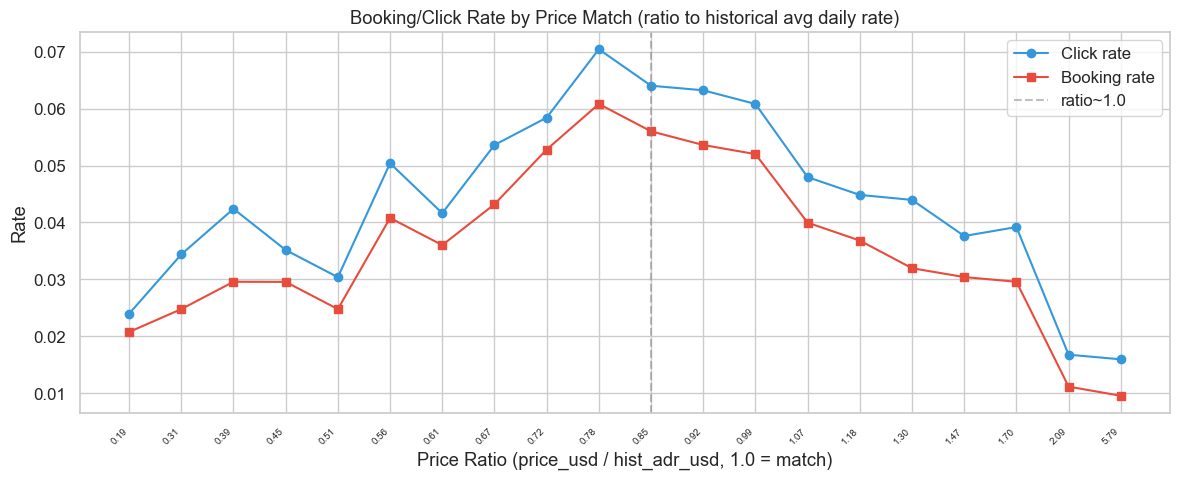

In [22]:
# Price match: price_ratio = price_usd / visitor_hist_adr_usd
subset = df[["price_usd", "visitor_hist_adr_usd", "booking_bool", "click_bool"]].dropna()
subset = subset[subset["visitor_hist_adr_usd"] > 0]
subset["price_ratio"] = subset["price_usd"] / subset["visitor_hist_adr_usd"]

# Clip extreme ratios for binning
subset_clipped = subset[(subset["price_ratio"] > 0.1) & (subset["price_ratio"] < 10)].copy()
subset_clipped["ratio_bin"] = pd.qcut(subset_clipped["price_ratio"], 20, duplicates="drop")
grouped = subset_clipped.groupby("ratio_bin", observed=True).agg(
    book_rate=("booking_bool", "mean"),
    click_rate=("click_bool", "mean"),
    count=("booking_bool", "size")
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(len(grouped)), grouped["click_rate"], "o-", label="Click rate", color="#3498db")
ax.plot(range(len(grouped)), grouped["book_rate"], "s-", label="Booking rate", color="#e74c3c")
ax.set_xticks(range(len(grouped)))
ax.set_xticklabels([f"{b.mid:.2f}" for b in grouped["ratio_bin"]], rotation=45, ha="right", fontsize=7)
ax.set_xlabel("Price Ratio (price_usd / hist_adr_usd, 1.0 = match)")
ax.set_ylabel("Rate")
ax.set_title("Booking/Click Rate by Price Match (ratio to historical avg daily rate)")
ax.axvline(len(grouped)//2, color="gray", linestyle="--", alpha=0.5, label="ratio~1.0")
ax.legend()
plt.tight_layout()
plt.show()

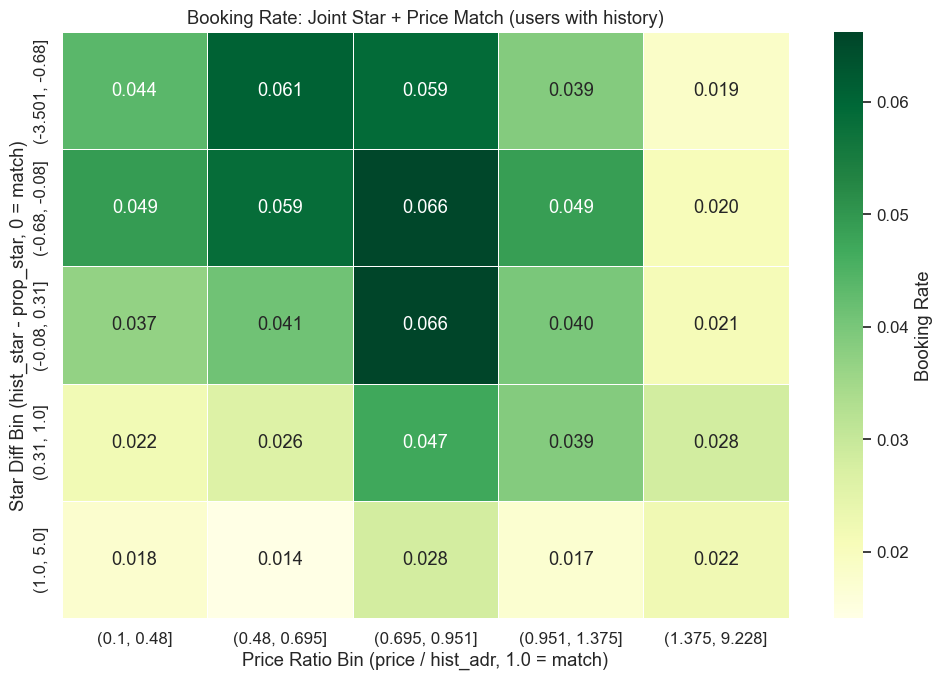

In [23]:
# Joint star+price match 2D heatmap
subset = df[["visitor_hist_starrating", "prop_starrating", "price_usd", 
              "visitor_hist_adr_usd", "booking_bool"]].dropna()
subset = subset[subset["visitor_hist_adr_usd"] > 0]
subset["star_diff"] = subset["visitor_hist_starrating"] - subset["prop_starrating"]
subset["price_ratio"] = subset["price_usd"] / subset["visitor_hist_adr_usd"]

# Clip for binning
subset = subset[(subset["price_ratio"] > 0.1) & (subset["price_ratio"] < 10)]
subset["star_diff_bin"] = pd.qcut(subset["star_diff"], 5, duplicates="drop")
subset["price_ratio_bin"] = pd.qcut(subset["price_ratio"], 5, duplicates="drop")

pivot = subset.pivot_table(values="booking_bool", index="star_diff_bin", 
                            columns="price_ratio_bin", aggfunc="mean", observed=True)
pivot_count = subset.pivot_table(values="booking_bool", index="star_diff_bin", 
                                  columns="price_ratio_bin", aggfunc="size", observed=True).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGn", ax=ax, linewidths=0.5,
            cbar_kws={"label": "Booking Rate"})
ax.set_xlabel("Price Ratio Bin (price / hist_adr, 1.0 = match)")
ax.set_ylabel("Star Diff Bin (hist_star - prop_star, 0 = match)")
ax.set_title("Booking Rate: Joint Star + Price Match (users with history)")
plt.tight_layout()
plt.show()

### Key Findings -- 3.5

- Users **with booking history** likely have higher click/booking rates overall -- they are repeat/loyal customers.
- **Star rating match** matters: users tend to book hotels matching their historical star preference (star_diff near 0).
- **Price match** matters: price_ratio near 1.0 (matching historical ADR) likely shows peak booking rates. Users are anchored to their past price level.
- The **joint 2D heatmap** should show the "perfect match" cell (star_diff~0, price_ratio~1) with the highest booking rate.
- Proposed features: `star_diff = visitor_hist_starrating - prop_starrating`, `price_ratio = price_usd / visitor_hist_adr_usd`, `has_visitor_history` (binary flag), `abs_star_diff`, `log_price_ratio`.

## 3.6 Competitor Features Analysis

Each hotel listing has up to 8 competitor comparisons. These features are heavily sparse (mostly NULL). We analyze which competitors matter, and whether aggregate measures (number of cheaper/expensive competitors) are predictive.

In [24]:
# Per-competitor summary table
comp_summary_rows = []
for i in range(1, 9):
    rate_col = f"comp{i}_rate"
    inv_col = f"comp{i}_inv"
    pct_col = f"comp{i}_rate_percent_diff"
    
    rate_nonnull = df[rate_col].notna().mean()
    inv_nonnull = df[inv_col].notna().mean()
    pct_nonnull = df[pct_col].notna().mean()
    
    # Distribution of rate values when non-null
    rate_vals = df[rate_col].dropna()
    pct_minus1 = (rate_vals == -1).mean() if len(rate_vals) > 0 else 0
    pct_zero = (rate_vals == 0).mean() if len(rate_vals) > 0 else 0
    pct_plus1 = (rate_vals == 1).mean() if len(rate_vals) > 0 else 0
    
    mean_pct = df[pct_col].mean()
    
    comp_summary_rows.append({
        "competitor": f"comp{i}",
        "rate_non_null%": f"{rate_nonnull:.1%}",
        "inv_non_null%": f"{inv_nonnull:.1%}",
        "pct_diff_non_null%": f"{pct_nonnull:.1%}",
        "rate=-1 (cheaper)": f"{pct_minus1:.1%}",
        "rate=0 (same)": f"{pct_zero:.1%}",
        "rate=+1 (expensive)": f"{pct_plus1:.1%}",
        "mean_pct_diff": f"{mean_pct:.2f}" if pd.notna(mean_pct) else "N/A"
    })

comp_summary = pd.DataFrame(comp_summary_rows)
display(comp_summary)

,competitor,rate_non_null%,inv_non_null%,pct_diff_non_null%,rate=-1 (cheaper),rate=0 (same),rate=+1 (expensive),mean_pct_diff
0,comp1,2.5%,2.7%,1.9%,7.8%,36.0%,56.2%,212.90
1,comp2,40.7%,42.7%,11.2%,8.0%,79.6%,12.4%,18.46
2,comp3,30.8%,33.0%,9.5%,9.6%,78.9%,11.4%,32.59
3,comp4,6.3%,7.0%,2.7%,16.7%,67.1%,16.2%,216.75
4,comp5,44.6%,47.3%,16.8%,12.5%,72.8%,14.7%,31.61
5,comp6,4.8%,5.2%,1.9%,10.3%,67.1%,22.7%,17.28
6,comp7,6.3%,7.1%,2.8%,10.4%,64.7%,24.9%,19.06
7,comp8,38.3%,39.7%,12.2%,14.3%,77.6%,8.2%,22.79


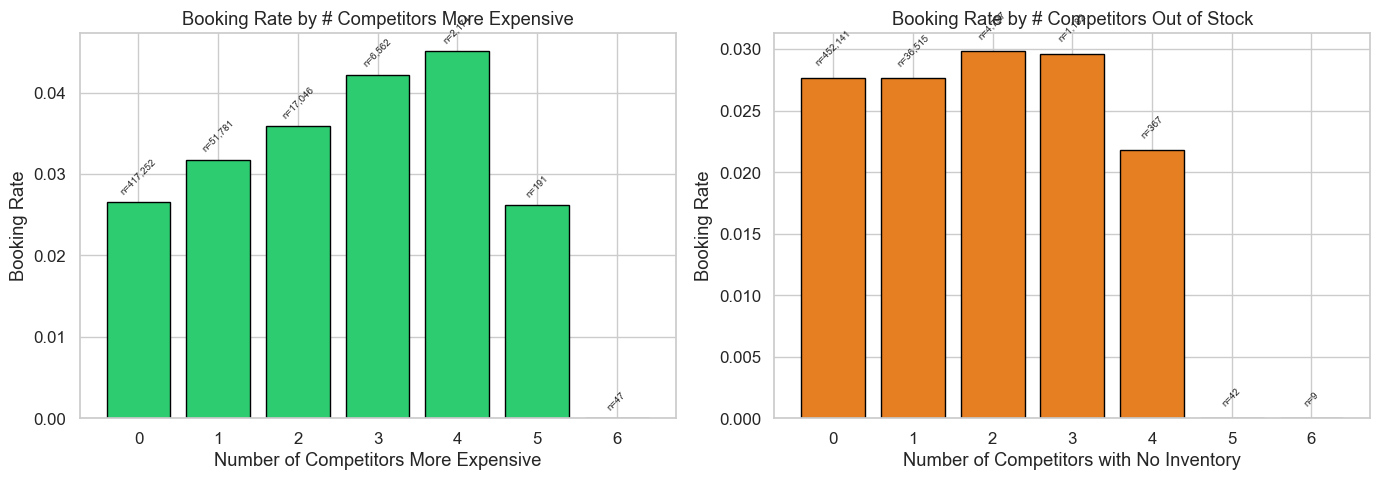

In [25]:
# Competitive advantage: n_comp_more_expensive vs booking rate
# Build on full df for this
df["n_comp_expensive"] = df[COMP_RATE_COLS].apply(lambda row: (row == 1).sum(), axis=1)
df["n_comp_cheaper"] = df[COMP_RATE_COLS].apply(lambda row: (row == -1).sum(), axis=1)
df["n_comp_no_inv"] = df[COMP_INV_COLS].apply(lambda row: (row == 1).sum(), axis=1)

grouped = df.groupby("n_comp_expensive").agg(
    book_rate=("booking_bool", "mean"),
    count=("booking_bool", "size")
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Competitors more expensive
ax = axes[0]
ax.bar(grouped["n_comp_expensive"], grouped["book_rate"], color="#2ecc71", edgecolor="black")
for _, row in grouped.iterrows():
    ax.text(row["n_comp_expensive"], row["book_rate"] + 0.001, f'n={int(row["count"]):,}', 
            ha="center", fontsize=7, rotation=45)
ax.set_xlabel("Number of Competitors More Expensive")
ax.set_ylabel("Booking Rate")
ax.set_title("Booking Rate by # Competitors More Expensive")

# Competitors no inventory
grouped_inv = df.groupby("n_comp_no_inv").agg(
    book_rate=("booking_bool", "mean"),
    count=("booking_bool", "size")
).reset_index()

ax = axes[1]
ax.bar(grouped_inv["n_comp_no_inv"], grouped_inv["book_rate"], color="#e67e22", edgecolor="black")
for _, row in grouped_inv.iterrows():
    ax.text(row["n_comp_no_inv"], row["book_rate"] + 0.001, f'n={int(row["count"]):,}', 
            ha="center", fontsize=7, rotation=45)
ax.set_xlabel("Number of Competitors with No Inventory")
ax.set_ylabel("Booking Rate")
ax.set_title("Booking Rate by # Competitors Out of Stock")

plt.tight_layout()
plt.show()

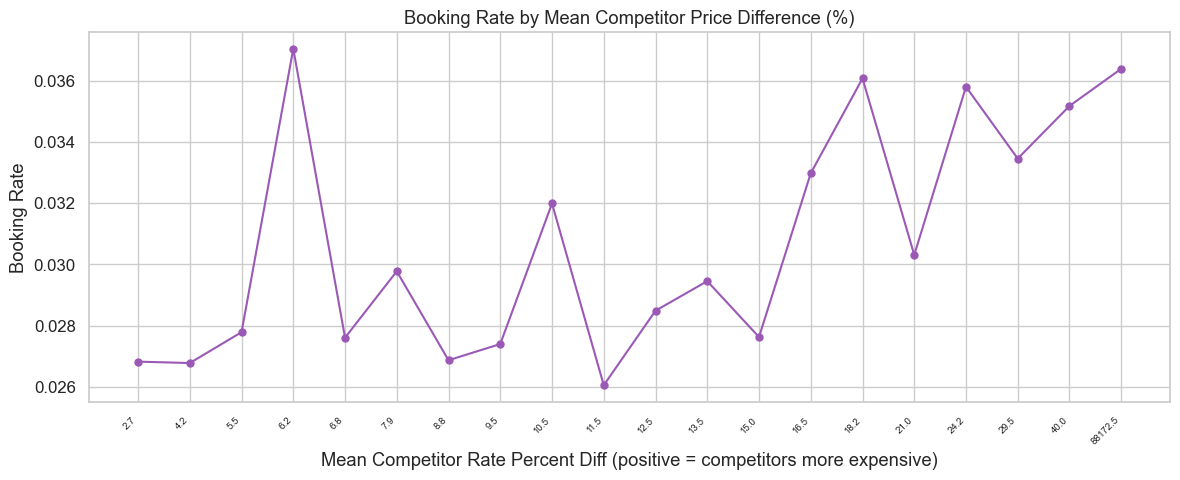

In [26]:
# Rate percent diff vs booking rate (mean across all comp pct_diff columns)
df["mean_comp_pct_diff"] = df[COMP_PCT_COLS].mean(axis=1)
subset = df[["mean_comp_pct_diff", "booking_bool"]].dropna()
subset["pct_bin"] = pd.qcut(subset["mean_comp_pct_diff"], 20, duplicates="drop")
grouped = subset.groupby("pct_bin", observed=True).agg(
    book_rate=("booking_bool", "mean"),
    count=("booking_bool", "size")
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(len(grouped)), grouped["book_rate"], "o-", color="#9b59b6", markersize=5)
ax.set_xticks(range(len(grouped)))
ax.set_xticklabels([f"{b.mid:.1f}" for b in grouped["pct_bin"]], rotation=45, ha="right", fontsize=7)
ax.set_xlabel("Mean Competitor Rate Percent Diff (positive = competitors more expensive)")
ax.set_ylabel("Booking Rate")
ax.set_title("Booking Rate by Mean Competitor Price Difference (%)")
plt.tight_layout()
plt.show()

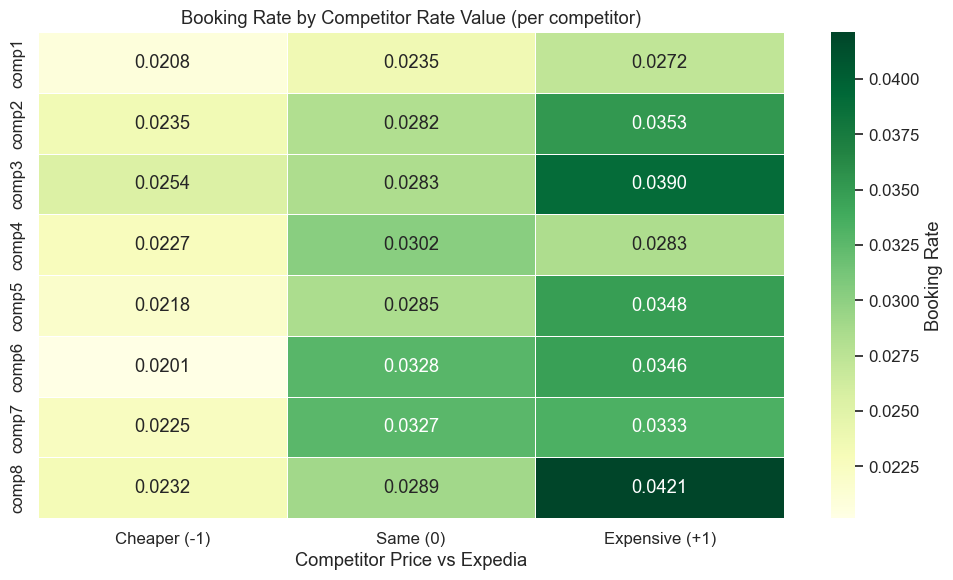

In [27]:
# Are all 8 competitors equal? Booking rate by rate value per competitor
comp_book_data = []
for i in range(1, 9):
    rate_col = f"comp{i}_rate"
    for val, label in [(-1, "cheaper"), (0, "same"), (1, "expensive")]:
        mask = df[rate_col] == val
        if mask.sum() > 0:
            br = df.loc[mask, "booking_bool"].mean()
            comp_book_data.append({"competitor": f"comp{i}", "rate_value": val, 
                                    "rate_label": label, "booking_rate": br, "count": mask.sum()})

comp_book_df = pd.DataFrame(comp_book_data)
pivot = comp_book_df.pivot(index="competitor", columns="rate_value", values="booking_rate")
pivot.columns = ["Cheaper (-1)", "Same (0)", "Expensive (+1)"]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlGn", ax=ax, linewidths=0.5,
            cbar_kws={"label": "Booking Rate"})
ax.set_title("Booking Rate by Competitor Rate Value (per competitor)")
ax.set_xlabel("Competitor Price vs Expedia")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Key Findings -- 3.6

- **Competitor data is heavily sparse** -- most comp columns are NULL for the majority of rows. Aggregation (n_comp_expensive, n_comp_cheaper) is more robust than individual comp features.
- **More expensive competitors = higher booking rate**: when more competitors are pricier, Expedia's listing becomes relatively attractive.
- **Competitor inventory stock-outs** may also boost bookings -- fewer alternatives available.
- **Not all competitors are equal**: some comp indices may show stronger effects than others. The heatmap reveals whether some competitors are more relevant to user decisions.
- Proposed features: `n_comp_expensive`, `n_comp_cheaper`, `n_comp_no_inv`, `mean_comp_pct_diff`, `max_comp_pct_diff`, `has_any_comp_data` (binary).

## 3.7 Geographic & Cross-Country Patterns

Analyzing how property country, visitor country, domestic vs international travel, and destination distance affect booking behavior.

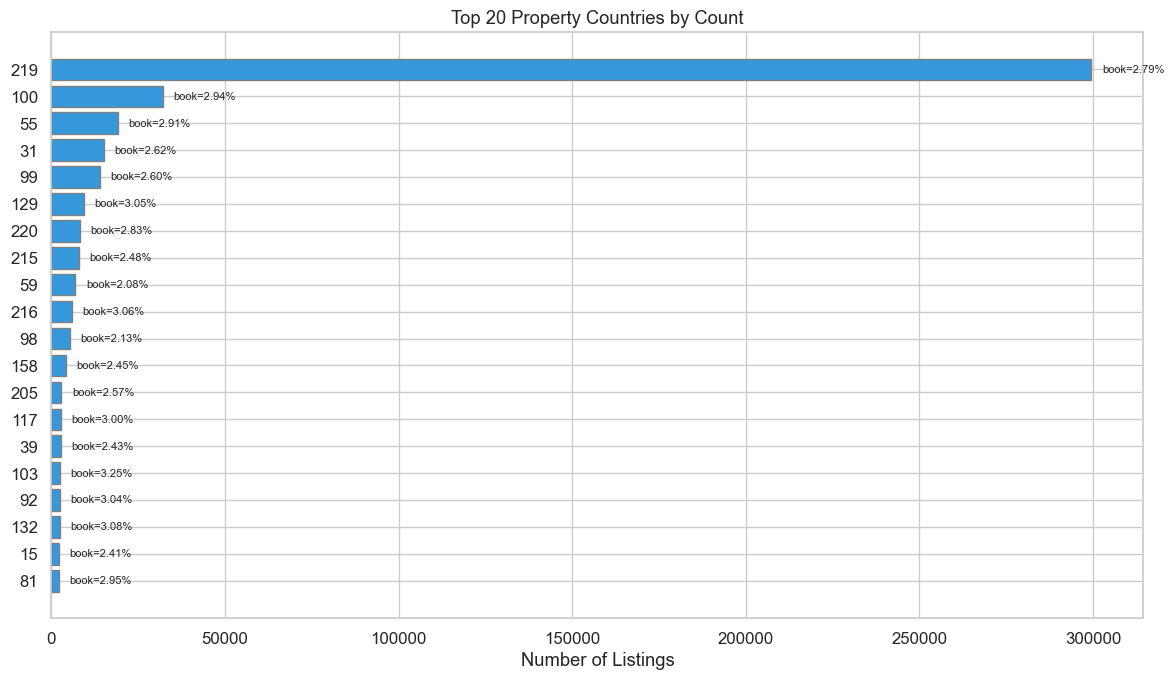

In [28]:
# Top 20 property countries
prop_country = df.groupby("prop_country_id").agg(
    count=("booking_bool", "size"),
    book_rate=("booking_bool", "mean")
).reset_index().sort_values("count", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(range(len(prop_country)), prop_country["count"].values, color="#3498db", edgecolor="gray")
ax.set_yticks(range(len(prop_country)))
ax.set_yticklabels(prop_country["prop_country_id"].values)
ax.set_xlabel("Number of Listings")
ax.set_title("Top 20 Property Countries by Count")
ax.invert_yaxis()

# Annotate with booking rate
for i, (_, row) in enumerate(prop_country.iterrows()):
    ax.text(row["count"] + prop_country["count"].max() * 0.01, i, 
            f'book={row["book_rate"]:.2%}', va="center", fontsize=8)

plt.tight_layout()
plt.show()

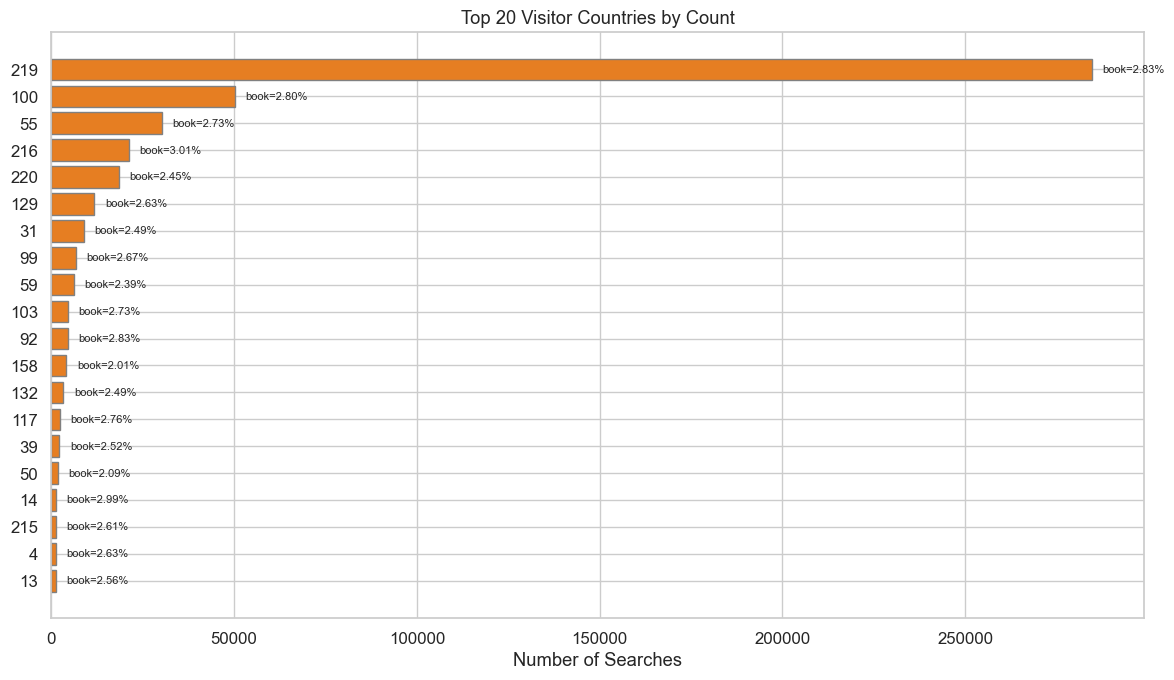

In [29]:
# Top 20 visitor countries
vis_country = df.groupby("visitor_location_country_id").agg(
    count=("booking_bool", "size"),
    book_rate=("booking_bool", "mean")
).reset_index().sort_values("count", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(range(len(vis_country)), vis_country["count"].values, color="#e67e22", edgecolor="gray")
ax.set_yticks(range(len(vis_country)))
ax.set_yticklabels(vis_country["visitor_location_country_id"].values)
ax.set_xlabel("Number of Searches")
ax.set_title("Top 20 Visitor Countries by Count")
ax.invert_yaxis()

for i, (_, row) in enumerate(vis_country.iterrows()):
    ax.text(row["count"] + vis_country["count"].max() * 0.01, i, 
            f'book={row["book_rate"]:.2%}', va="center", fontsize=8)

plt.tight_layout()
plt.show()

Fraction of domestic searches: 63.4%


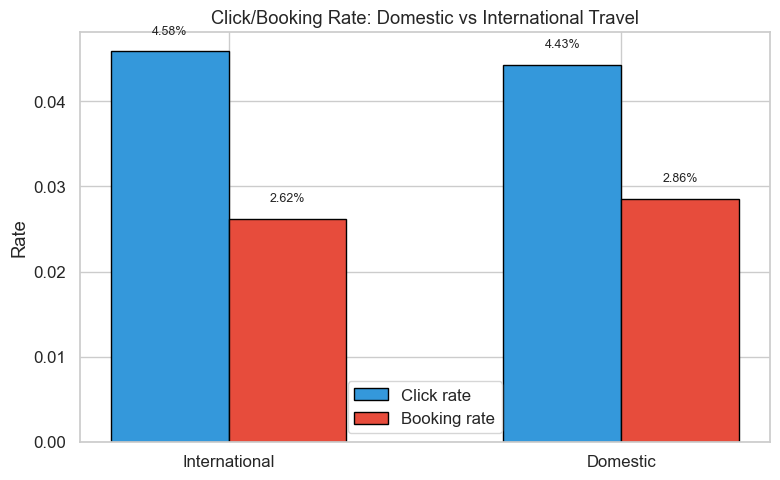

In [30]:
# Domestic vs international
df["is_domestic"] = (df["visitor_location_country_id"] == df["prop_country_id"]).astype(int)
domestic_frac = df["is_domestic"].mean()
print(f"Fraction of domestic searches: {domestic_frac:.1%}")

dom_stats = df.groupby("is_domestic").agg(
    click_rate=("click_bool", "mean"),
    book_rate=("booking_bool", "mean"),
    count=("booking_bool", "size")
).reset_index()
dom_stats["label"] = dom_stats["is_domestic"].map({0: "International", 1: "Domestic"})

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
w = 0.3
ax.bar(x - w/2, dom_stats["click_rate"], w, label="Click rate", color="#3498db", edgecolor="black")
ax.bar(x + w/2, dom_stats["book_rate"], w, label="Booking rate", color="#e74c3c", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(dom_stats["label"])
ax.set_ylabel("Rate")
ax.set_title("Click/Booking Rate: Domestic vs International Travel")
ax.legend()
for i, row in dom_stats.iterrows():
    ax.text(i - w/2, row["click_rate"] + 0.002, f'{row["click_rate"]:.2%}', ha="center", fontsize=9)
    ax.text(i + w/2, row["book_rate"] + 0.002, f'{row["book_rate"]:.2%}', ha="center", fontsize=9)
plt.tight_layout()
plt.show()

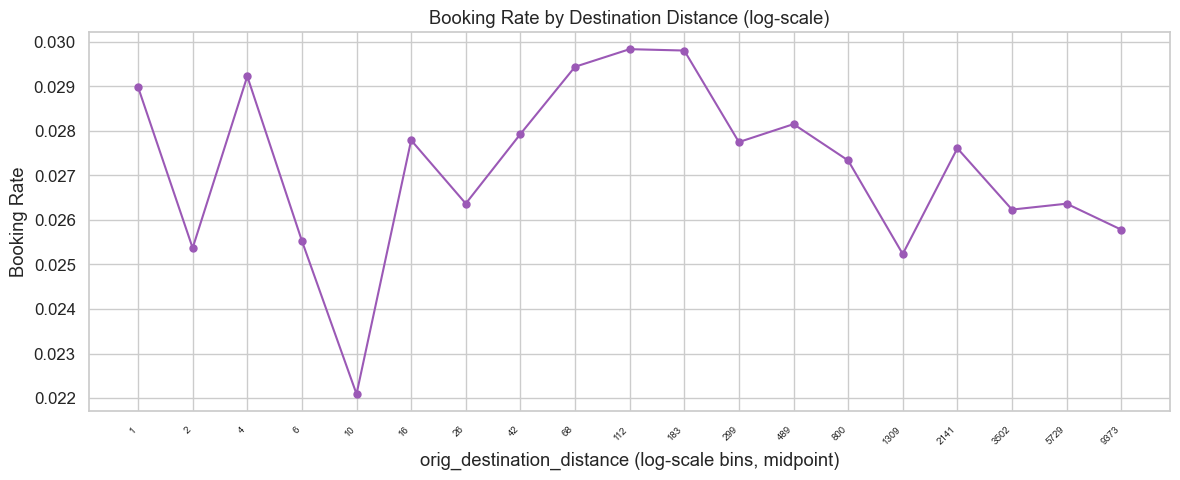


orig_destination_distance: 33.1% missing


  Missing -> book rate: 2.747%
  Present -> book rate: 2.779%


In [31]:
# orig_destination_distance vs booking rate (log-scale bins)
subset = df[["orig_destination_distance", "booking_bool"]].dropna()
subset = subset[subset["orig_destination_distance"] > 0]

# Log-scale bins
bins = np.logspace(np.log10(subset["orig_destination_distance"].min() + 1), 
                    np.log10(subset["orig_destination_distance"].max()), 20)
subset["dist_bin"] = pd.cut(subset["orig_destination_distance"], bins=bins)
grouped = subset.groupby("dist_bin", observed=True).agg(
    book_rate=("booking_bool", "mean"),
    count=("booking_bool", "size")
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(len(grouped)), grouped["book_rate"], "o-", color="#9b59b6", markersize=5)
ax.set_xticks(range(len(grouped)))
ax.set_xticklabels([f"{b.mid:.0f}" for b in grouped["dist_bin"]], rotation=45, ha="right", fontsize=7)
ax.set_xlabel("orig_destination_distance (log-scale bins, midpoint)")
ax.set_ylabel("Booking Rate")
ax.set_title("Booking Rate by Destination Distance (log-scale)")
plt.tight_layout()
plt.show()

# Missing distance stats
dist_null = df["orig_destination_distance"].isna()
print(f"\norig_destination_distance: {dist_null.mean():.1%} missing")
print(f"  Missing -> book rate: {df.loc[dist_null, 'booking_bool'].mean():.3%}")
print(f"  Present -> book rate: {df.loc[~dist_null, 'booking_bool'].mean():.3%}")

Number of unique sites: 32


,site_id,count,book_rate,click_rate
4,5,303606,0.028086,0.043889
12,14,48785,0.027775,0.043825
13,15,32206,0.027107,0.045519
21,24,23361,0.030607,0.046916
29,32,18980,0.024763,0.044942
16,18,12444,0.026519,0.049100
14,16,8891,0.024182,0.047239
10,12,7489,0.025237,0.050073
9,11,4352,0.027344,0.043428
7,9,4333,0.021694,0.049388


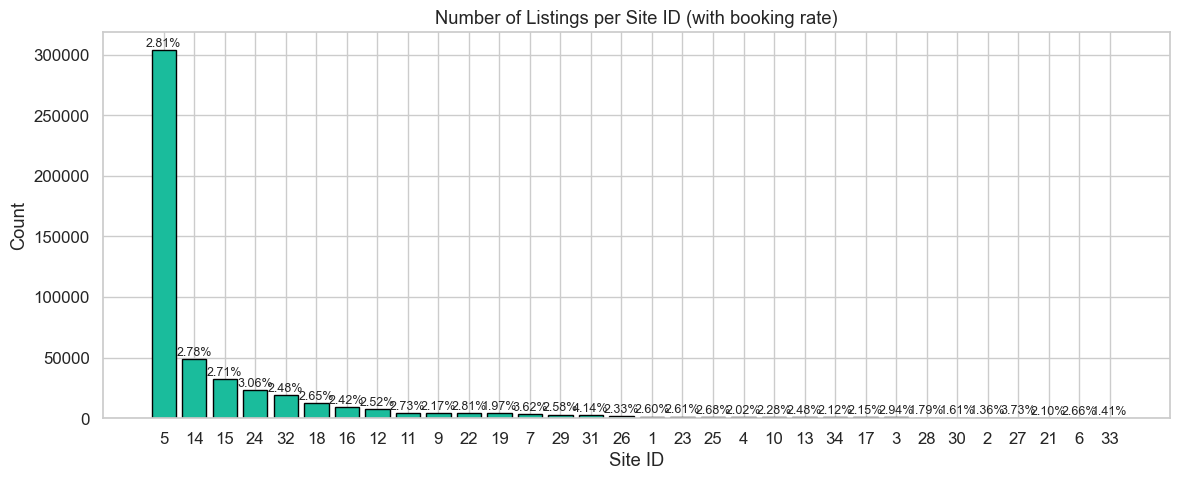

In [32]:
# Site-level analysis
site_stats = df.groupby("site_id").agg(
    count=("booking_bool", "size"),
    book_rate=("booking_bool", "mean"),
    click_rate=("click_bool", "mean")
).reset_index().sort_values("count", ascending=False)

print(f"Number of unique sites: {len(site_stats)}")
display(site_stats)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(site_stats))
ax.bar(x, site_stats["count"].values, color="#1abc9c", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(site_stats["site_id"].values)
ax.set_xlabel("Site ID")
ax.set_ylabel("Count")
ax.set_title("Number of Listings per Site ID (with booking rate)")

# Add booking rate as text
for i, (_, row) in enumerate(site_stats.iterrows()):
    ax.text(i, row["count"] + site_stats["count"].max() * 0.01, 
            f'{row["book_rate"]:.2%}', ha="center", fontsize=9, rotation=0)

plt.tight_layout()
plt.show()

### Key Findings -- 3.7

- **Domestic travel** likely has a higher booking rate than international -- users are more confident booking familiar destinations.
- **Property and visitor country distributions** are skewed -- a few countries dominate, with varying booking rates.
- **Destination distance** shows a non-linear pattern: very close and very far distances may have different booking behaviors. Log-distance is a good feature transformation.
- **Site ID** acts as a contextual variable -- different Expedia regional sites serve different markets with different booking patterns. It's constant within a query.
- Proposed features: `is_domestic`, `log_distance`, `distance_missing_flag`.

## 3.8 Within-Query Variance Analysis (MOST IMPORTANT)

**LambdaRank ranks hotels within a single search query.** This means features that are **constant within a query** (e.g., srch_length_of_stay, srch_adults_count) provide **zero ranking signal** as raw features -- every hotel in the query has the same value.

The critical question is: **which features actually vary within a query?**

- **Tier 1 (high within-query variance ratio > 0.3):** These features differ across hotels in the same query. They directly help the model rank one hotel above another. Examples: price_usd, prop_starrating, prop_location_score.
- **Tier 2 (near-zero ratio < 0.01):** These features are identical for all hotels in a query. As raw inputs, they cannot distinguish hotels. However, they are valuable when **interacted with Tier 1 features** (e.g., price_per_night = price_usd / srch_length_of_stay creates query-level context).
- **Tier 3 (in between):** Partially varying features -- some variation within queries but also significant between-query variation.

This analysis is the foundation for feature engineering decisions.

In [33]:
# Variance ratio table: within-query variance / total variance
print("Computing within-query variance ratios...")

# Get all numeric columns (excluding targets and IDs)
exclude_cols = {"srch_id", "prop_id", "position", "click_bool", "booking_bool", 
                "gross_bookings_usd", "relevance", "random_bool", "date_time",
                "is_domestic", "n_comp_expensive", "n_comp_cheaper", "n_comp_no_inv", "mean_comp_pct_diff"}
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude_cols]

variance_rows = []
for i, col in enumerate(numeric_cols):
    if (i + 1) % 10 == 0:
        print(f"  Processing {i+1}/{len(numeric_cols)}: {col}")
    
    total_var = df[col].var()
    if total_var == 0 or pd.isna(total_var):
        continue
    
    # Within-query variance: mean of per-group variances
    within_var = df.groupby("srch_id")[col].var().mean()
    if pd.isna(within_var):
        within_var = 0
    
    ratio = within_var / total_var
    
    # Classify tier
    if ratio > 0.3:
        tier = "Tier 1 (ranking signal)"
    elif ratio < 0.01:
        tier = "Tier 2 (constant in query)"
    else:
        tier = "Tier 3 (partial)"
    
    variance_rows.append({
        "feature": col,
        "total_variance": total_var,
        "within_query_variance": within_var,
        "variance_ratio": ratio,
        "tier": tier
    })

var_df = pd.DataFrame(variance_rows).sort_values("variance_ratio", ascending=False).reset_index(drop=True)
print(f"\nDone. {len(var_df)} features analyzed.")

# Display with tier colors
def color_tier(row):
    if "Tier 1" in row["tier"]:
        return ["background-color: #d5f5e3"] * len(row)
    elif "Tier 2" in row["tier"]:
        return ["background-color: #fadbd8"] * len(row)
    else:
        return ["background-color: #fdebd0"] * len(row)

styled = (var_df.style
          .apply(color_tier, axis=1)
          .format({"total_variance": "{:.4f}", "within_query_variance": "{:.4f}", 
                   "variance_ratio": "{:.4f}"}))
display(styled)

# Summary counts
print("\nTier summary:")
print(var_df["tier"].value_counts().to_string())

Computing within-query variance ratios...


  Processing 10/46: prop_location_score2
  Processing 20/46: srch_saturday_night_bool
  Processing 30/46: comp3_inv


  Processing 40/46: comp6_rate_percent_diff

Done. 46 features analyzed.


,feature,total_variance,within_query_variance,variance_ratio,tier
0,comp8_inv,0.0405,0.0475,1.1715,Tier 1 (ranking signal)
1,comp3_rate,0.2106,0.2293,1.0887,Tier 1 (ranking signal)
2,comp5_rate,0.2717,0.2818,1.0375,Tier 1 (ranking signal)
3,comp8_rate,0.2205,0.2284,1.0359,Tier 1 (ranking signal)
4,comp2_rate,0.2020,0.2086,1.0329,Tier 1 (ranking signal)
5,comp7_rate,0.3323,0.3401,1.0236,Tier 1 (ranking signal)
6,comp2_inv,0.0528,0.0536,1.0146,Tier 1 (ranking signal)
7,comp6_rate,0.3139,0.3080,0.9814,Tier 1 (ranking signal)
8,comp6_inv,0.0914,0.0882,0.9645,Tier 1 (ranking signal)
9,comp6_rate_percent_diff,885.9568,851.6040,0.9612,Tier 1 (ranking signal)



Tier summary:
tier
Tier 1 (ranking signal)       28
Tier 2 (constant in query)    13
Tier 3 (partial)               5


### Explicit Interaction Proposals for Tier 2 Features

Tier 2 features are constant within a query and cannot rank hotels directly. But they provide **context** that changes how Tier 1 features should be interpreted:

| Tier 2 Feature | x Tier 1 Feature | Proposed Interaction | Rationale |
|---|---|---|---|
| `srch_length_of_stay` | `price_usd` | `price_per_night = price_usd / max(length_of_stay, 1)` | Normalizes total price to nightly rate for fair comparison |
| `srch_booking_window` | `price_usd` | `price_x_booking_window` | Last-minute bookers may be less price-sensitive |
| `srch_adults_count` | `price_usd` | `price_per_person = price_usd / adults_count` | Per-person cost matters for group travel |
| `srch_room_count` | `price_usd` | `price_per_room = price_usd / room_count` | Multi-room bookings evaluate per-room cost |
| `visitor_location_country_id` | `prop_country_id` | `is_domestic = (visitor == prop country)` | Domestic vs international context |
| `site_id` | (all features) | Contextual modifier / group-by encoding | Different sites serve different markets |
| `srch_saturday_night_bool` | `price_usd` | Weekend vs weekday pricing sensitivity | Weekend travelers may have different price tolerance |
| `srch_children_count` | `prop_starrating` | Family-friendliness context | Families may prefer certain star levels |

Computing within-query price statistics...



Within-query price spread summary:
  Mean std(price):   $77.56
  Median std(price): $50.75
  Mean range:        $304.29
  Mean IQR:          $78.05


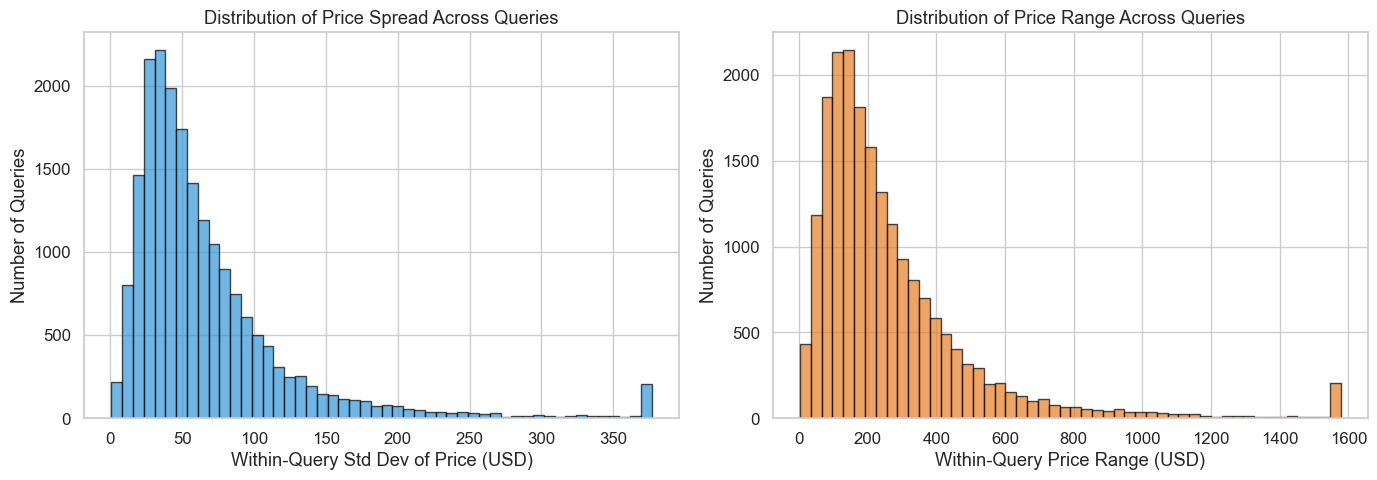

In [34]:
# Within-query price spread
print("Computing within-query price statistics...")
price_stats = df.groupby("srch_id")["price_usd"].agg(["std", "min", "max", "median"]).dropna()
price_stats["range"] = price_stats["max"] - price_stats["min"]
price_stats["iqr"] = df.groupby("srch_id")["price_usd"].apply(
    lambda x: x.quantile(0.75) - x.quantile(0.25)
)

print("\nWithin-query price spread summary:")
print(f"  Mean std(price):   ${price_stats['std'].mean():.2f}")
print(f"  Median std(price): ${price_stats['std'].median():.2f}")
print(f"  Mean range:        ${price_stats['range'].mean():.2f}")
print(f"  Mean IQR:          ${price_stats['iqr'].mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of within-query price std
ax = axes[0]
ax.hist(price_stats["std"].clip(upper=price_stats["std"].quantile(0.99)), bins=50, 
        color="#3498db", edgecolor="black", alpha=0.7)
ax.set_xlabel("Within-Query Std Dev of Price (USD)")
ax.set_ylabel("Number of Queries")
ax.set_title("Distribution of Price Spread Across Queries")

# Histogram of within-query price range
ax = axes[1]
ax.hist(price_stats["range"].clip(upper=price_stats["range"].quantile(0.99)), bins=50, 
        color="#e67e22", edgecolor="black", alpha=0.7)
ax.set_xlabel("Within-Query Price Range (USD)")
ax.set_ylabel("Number of Queries")
ax.set_title("Distribution of Price Range Across Queries")

plt.tight_layout()
plt.show()

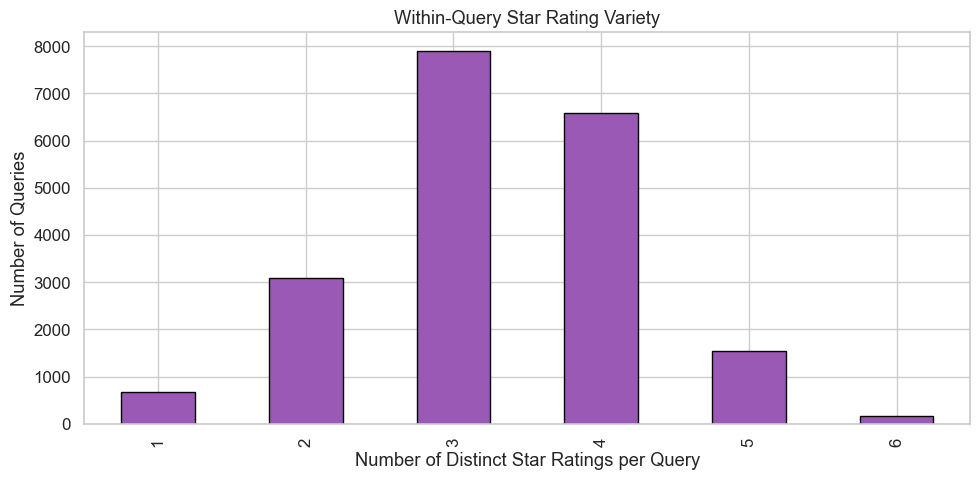

Mean distinct star ratings per query: 3.29
Queries with only 1 star rating: 678 (3.4%)


In [35]:
# Within-query star variety
star_variety = df.groupby("srch_id")["prop_starrating"].nunique()

fig, ax = plt.subplots(figsize=(10, 5))
star_variety.value_counts().sort_index().plot(kind="bar", ax=ax, color="#9b59b6", edgecolor="black")
ax.set_xlabel("Number of Distinct Star Ratings per Query")
ax.set_ylabel("Number of Queries")
ax.set_title("Within-Query Star Rating Variety")
plt.tight_layout()
plt.show()

print(f"Mean distinct star ratings per query: {star_variety.mean():.2f}")
print(f"Queries with only 1 star rating: {(star_variety == 1).sum():,} ({(star_variety == 1).mean():.1%})")

Computing within-query Spearman correlations with relevance (random_bool=1 data)...
This is the most direct ranking-quality measure.



Using 6,134 queries with >=5 hotels each


/var/folders/ph/1twx9qcn6gd50vvgj_05gts40000gn/T/ipykernel_22227/55869462.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.spearmanr(group[col], group["relevance"])


  comp8_inv: done (870 queries)


/var/folders/ph/1twx9qcn6gd50vvgj_05gts40000gn/T/ipykernel_22227/55869462.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.spearmanr(group[col], group["relevance"])


...

  prop_starrating: done (5850 queries)
  comp3_rate_percent_diff: done (378 queries)


/var/folders/ph/1twx9qcn6gd50vvgj_05gts40000gn/T/ipykernel_22227/55869462.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.spearmanr(group[col], group["relevance"])
/var/folders/ph/1twx9qcn6gd50vvgj_05gts40000gn/T/ipykernel_22227/55869462.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.spearmanr(group[col], group["relevance"])
/var/folders/ph/1twx9qcn6gd50vvgj_05gts40000gn/T/ipykernel_22227/55869462.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.spearmanr(group[col], group["relevance"])


  comp2_rate_percent_diff: done (416 queries)


  prop_location_score2: done (4954 queries)


  prop_location_score1: done (6130 queries)

Computed for 28 features.


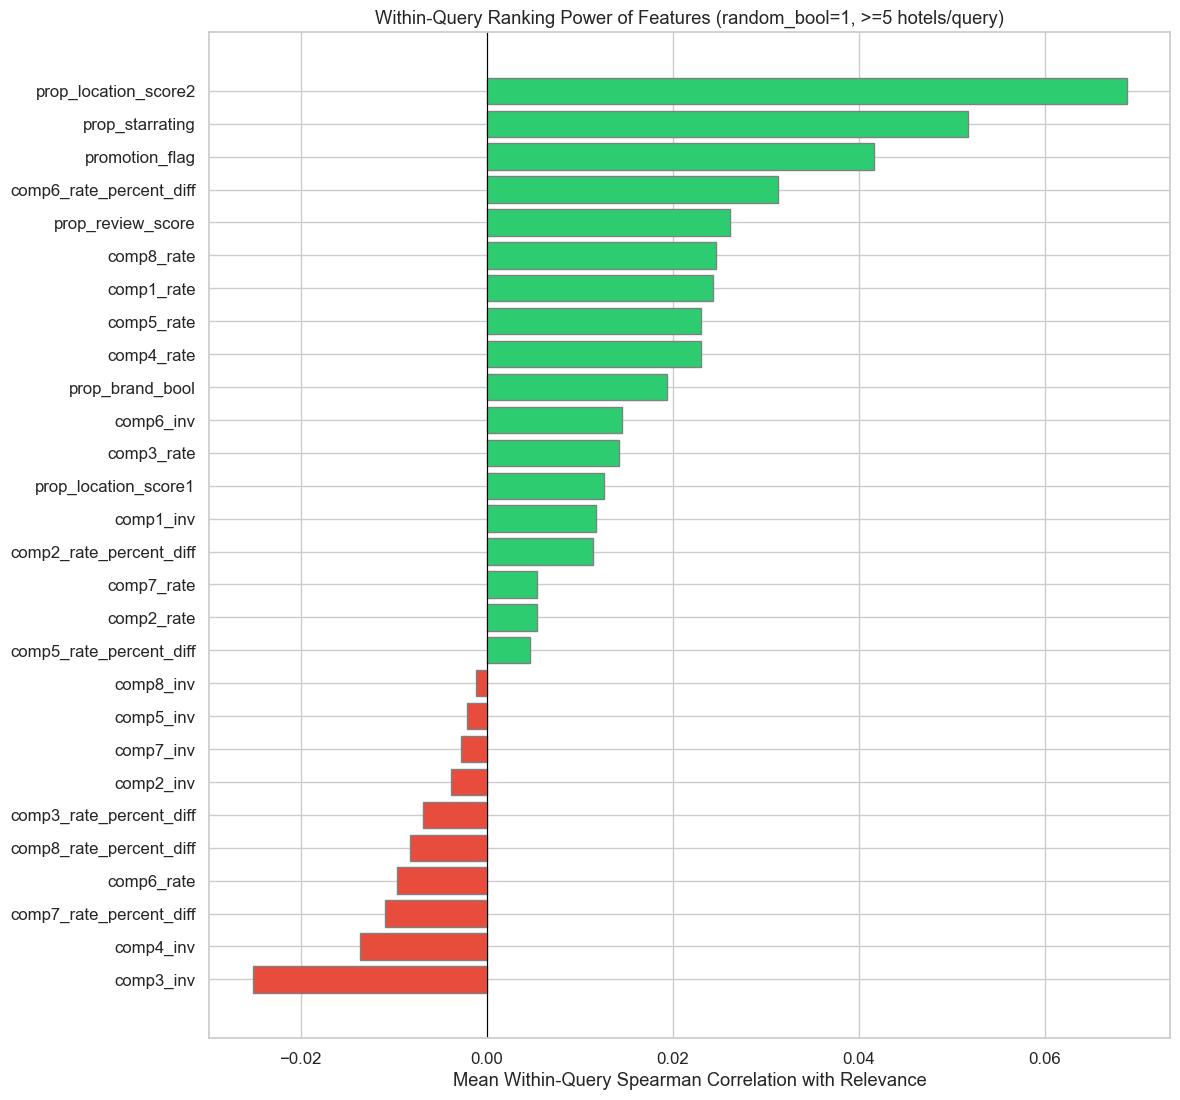

,feature,mean_within_spearman,median_within_spearman,n_queries
26,prop_location_score2,0.0688,0.0840,4954
23,prop_starrating,0.0517,0.0668,5850
20,promotion_flag,0.0416,-0.0636,5165
9,comp6_rate_percent_diff,0.0313,0.0000,82
13,prop_review_score,0.0262,0.0420,6116
3,comp8_rate,0.0247,0.0384,1738
18,comp1_rate,0.0243,0.0746,134
2,comp5_rate,0.0231,0.0000,2264
11,comp4_rate,0.0231,0.0248,375
22,prop_brand_bool,0.0194,0.0657,5578


In [36]:
# Within-query Spearman correlation with relevance (Tier 1 features)
# The most direct measure: "does this feature rank hotels correctly within a query?"
print("Computing within-query Spearman correlations with relevance (random_bool=1 data)...")
print("This is the most direct ranking-quality measure.\n")

tier1_features = var_df[var_df["tier"].str.contains("Tier 1")]["feature"].tolist()
# Also include some key Tier 3 features
tier1_plus = [f for f in tier1_features if f in df_rand.columns]

# Sample queries for speed (compute Spearman per query, then average)
rand_queries = df_rand.groupby("srch_id").filter(lambda x: len(x) >= 5)  # need >=5 hotels
query_ids = rand_queries["srch_id"].unique()
print(f"Using {len(query_ids):,} queries with >=5 hotels each")

within_corr_rows = []
for col in tier1_plus:
    query_corrs = []
    valid_data = rand_queries[["srch_id", col, "relevance"]].dropna()
    for qid, group in valid_data.groupby("srch_id"):
        if len(group) < 5 or group[col].nunique() < 2:
            continue
        r, _ = stats.spearmanr(group[col], group["relevance"])
        if not np.isnan(r):
            query_corrs.append(r)
    
    if len(query_corrs) > 0:
        within_corr_rows.append({
            "feature": col,
            "mean_within_spearman": np.mean(query_corrs),
            "median_within_spearman": np.median(query_corrs),
            "n_queries": len(query_corrs)
        })
    print(f"  {col}: done ({len(query_corrs)} queries)")

within_corr_df = pd.DataFrame(within_corr_rows).sort_values("mean_within_spearman", ascending=False)
print(f"\nComputed for {len(within_corr_df)} features.")

# Bar chart
fig, ax = plt.subplots(figsize=(12, max(6, len(within_corr_df) * 0.4)))
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in within_corr_df["mean_within_spearman"]]
ax.barh(range(len(within_corr_df)), within_corr_df["mean_within_spearman"].values, color=colors, edgecolor="gray")
ax.set_yticks(range(len(within_corr_df)))
ax.set_yticklabels(within_corr_df["feature"].values)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean Within-Query Spearman Correlation with Relevance")
ax.set_title("Within-Query Ranking Power of Features (random_bool=1, >=5 hotels/query)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(within_corr_df.style.format({"mean_within_spearman": "{:.4f}", 
                                       "median_within_spearman": "{:.4f}"}))

### Key Findings -- 3.8 (Most Actionable Section)

**Variance Ratio Classification:**
- **Tier 1 features** (high within-query variance) are the backbone of ranking: they include property-level attributes like `prop_starrating`, `prop_location_score1/2`, `prop_review_score`, `price_usd`, `prop_brand_bool`, competitor features, and `prop_log_historical_price`. These features differentiate hotels within the same search.
- **Tier 2 features** (near-zero within-query variance) include all search parameters (`srch_length_of_stay`, `srch_booking_window`, `srch_adults_count`, etc.) and visitor/geographic IDs. These are identical for every hotel in a query. As raw features in LambdaRank, they add zero ranking signal. Their value comes **only through interactions** with Tier 1 features.
- **Key insight:** Including raw Tier 2 features in the model is not harmful (tree models can learn interactions), but explicitly creating interaction features (e.g., `price_per_night`, `price_per_person`) gives the model a head start and can significantly boost performance.

**Within-Query Price Spread:**
- Price varies substantially within queries (high std), confirming that `price_usd` is a primary ranking discriminator.
- Computing `price_rank_in_query`, `price_z_score_in_query`, and `price_vs_query_median` are high-value engineered features.

**Within-Query Star Variety:**
- Most queries contain hotels across multiple star ratings, confirming that star rating is useful for ranking.

**Within-Query Spearman Correlation with Relevance:**
- This is the gold-standard measure: features with high positive within-query Spearman correlation (e.g., location scores) are the most directly useful.
- Features with negative within-query correlation (e.g., price) also provide strong signal -- the model just needs to learn the direction.
- Features with near-zero within-query correlation provide little ranking benefit even though they vary within queries.

## 3.9 Interaction Effects & Creative Features

Testing whether composite/interaction features predict bookings better than their components alone.

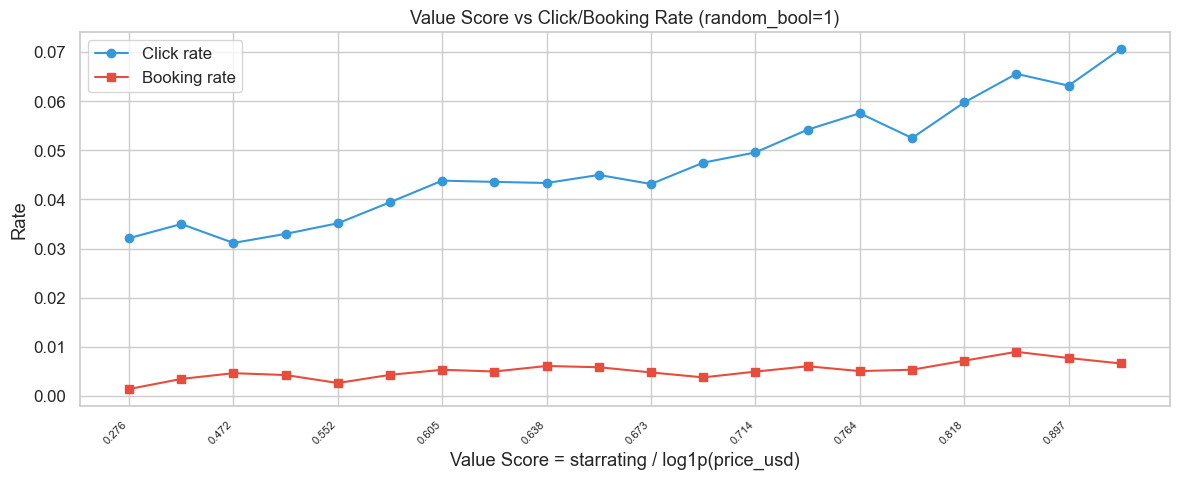

Spearman corr with booking_bool: value_score               -> r=0.0187 (p=1.56e-12)
Spearman corr with booking_bool: prop_starrating           -> r=0.0092 (p=5.38e-04)
Spearman corr with booking_bool: price_usd                 -> r=-0.0148 (p=2.58e-08)


In [37]:
# Value score: prop_starrating / log1p(price_usd)
subset = df_rand[["prop_starrating", "price_usd", "booking_bool", "click_bool"]].dropna()
subset = subset[subset["prop_starrating"] >= 1]
subset["value_score"] = subset["prop_starrating"] / np.log1p(subset["price_usd"])
subset["value_bin"] = pd.qcut(subset["value_score"], 20, duplicates="drop")

grouped = subset.groupby("value_bin", observed=True).agg(
    book_rate=("booking_bool", "mean"),
    click_rate=("click_bool", "mean"),
    count=("booking_bool", "size")
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(len(grouped)), grouped["click_rate"], "o-", label="Click rate", color="#3498db")
ax.plot(range(len(grouped)), grouped["book_rate"], "s-", label="Booking rate", color="#e74c3c")
ax.set_xticks(range(0, len(grouped), 2))
ax.set_xticklabels([f"{b.mid:.3f}" for b in grouped["value_bin"].iloc[::2]], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Value Score = starrating / log1p(price_usd)")
ax.set_ylabel("Rate")
ax.set_title("Value Score vs Click/Booking Rate (random_bool=1)")
ax.legend()
plt.tight_layout()
plt.show()

# Compare predictive power: value_score vs starrating alone vs price alone
for feat in ["value_score", "prop_starrating", "price_usd"]:
    valid = subset[[feat, "booking_bool"]].dropna()
    r, p = stats.spearmanr(valid[feat], valid["booking_bool"])
    print(f"Spearman corr with booking_bool: {feat:25s} -> r={r:.4f} (p={p:.2e})")

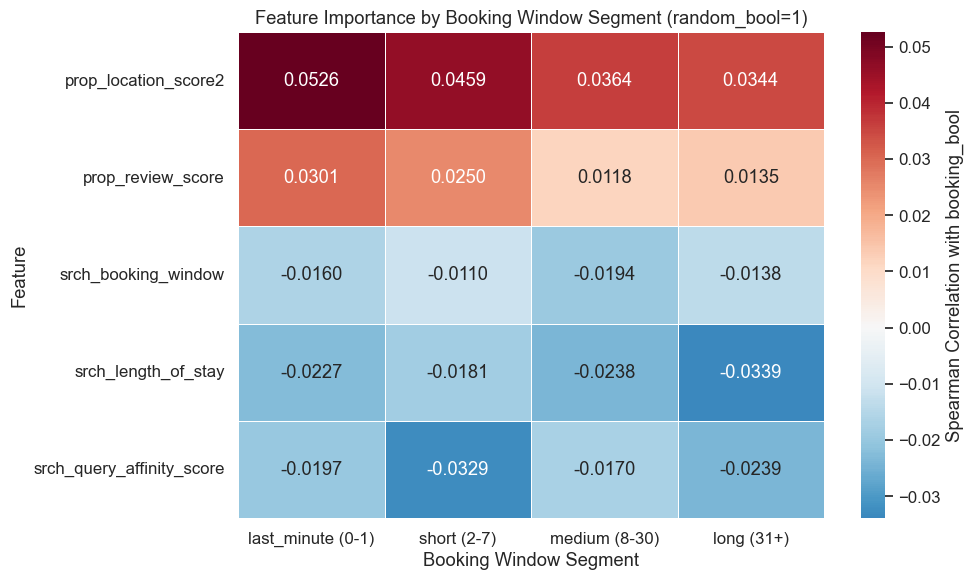

In [38]:
# Booking window segments: do different features matter for different urgency levels?
subset = df_rand.copy()
subset["bw_segment"] = pd.cut(subset["srch_booking_window"], 
                                bins=[-1, 1, 7, 30, 365],
                                labels=["last_minute (0-1)", "short (2-7)", "medium (8-30)", "long (31+)"])

top5_features = corr_df.head(5)["feature"].tolist()

# Compute Spearman correlation per segment per feature
seg_corr_data = []
for seg in subset["bw_segment"].dropna().unique():
    seg_data = subset[subset["bw_segment"] == seg]
    for feat in top5_features:
        valid = seg_data[[feat, "booking_bool"]].dropna()
        if len(valid) > 30:
            r, _ = stats.spearmanr(valid[feat], valid["booking_bool"])
            seg_corr_data.append({"segment": seg, "feature": feat, "spearman": r})

seg_corr_df = pd.DataFrame(seg_corr_data)
pivot = seg_corr_df.pivot(index="feature", columns="segment", values="spearman")

# Reorder columns logically
col_order = ["last_minute (0-1)", "short (2-7)", "medium (8-30)", "long (31+)"]
pivot = pivot[[c for c in col_order if c in pivot.columns]]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="RdBu_r", center=0, ax=ax, linewidths=0.5,
            cbar_kws={"label": "Spearman Correlation with booking_bool"})
ax.set_title("Feature Importance by Booking Window Segment (random_bool=1)")
ax.set_xlabel("Booking Window Segment")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

Family vs Solo/Couple comparison:


,segment,booking_rate,click_rate,mean_booked_price,mean_booked_stars,count
0,Family,0.005819,0.049079,138.740799,3.310000,34373
1,Solo/Couple,0.004904,0.046111,133.444000,3.305755,113379


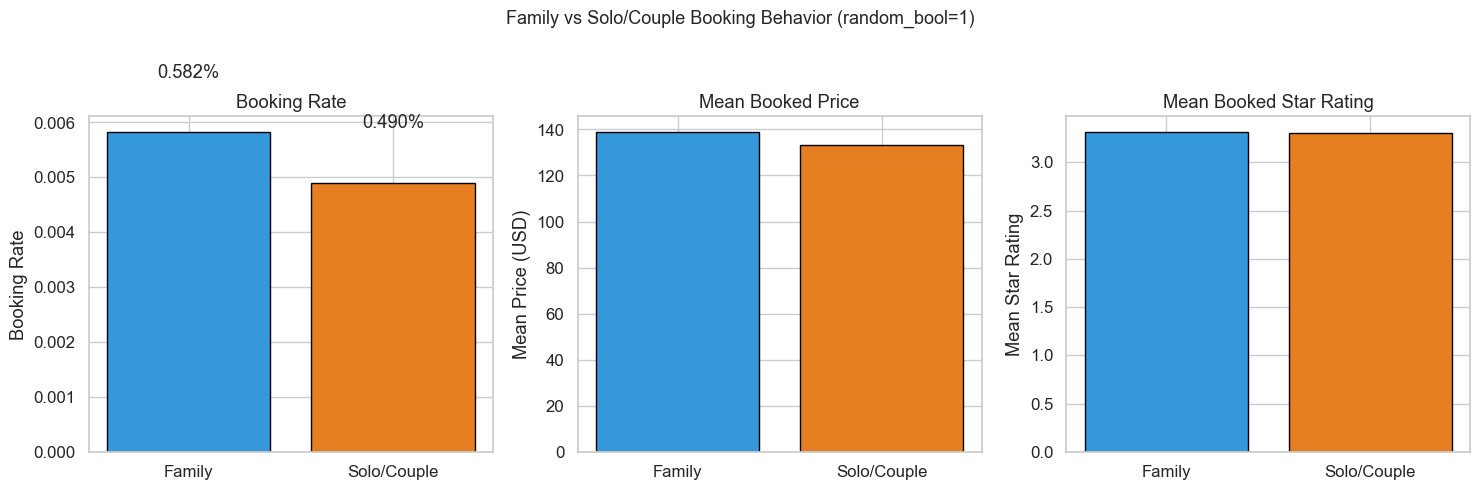

In [39]:
# Family vs solo/couple comparison
subset = df_rand.copy()
subset["is_family"] = (subset["srch_children_count"] > 0).astype(int)
subset["segment"] = subset["is_family"].map({0: "Solo/Couple", 1: "Family"})

# Compare across segments
family_comp = subset.groupby("segment").agg(
    booking_rate=("booking_bool", "mean"),
    click_rate=("click_bool", "mean"),
    mean_booked_price=("price_usd", lambda x: x[subset.loc[x.index, "booking_bool"] == 1].mean() 
                        if (subset.loc[x.index, "booking_bool"] == 1).any() else np.nan),
    mean_booked_stars=("prop_starrating", lambda x: x[subset.loc[x.index, "booking_bool"] == 1].mean()
                        if (subset.loc[x.index, "booking_bool"] == 1).any() else np.nan),
    count=("booking_bool", "size")
).reset_index()

print("Family vs Solo/Couple comparison:")
display(family_comp)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Booking rate
ax = axes[0]
ax.bar(family_comp["segment"], family_comp["booking_rate"], color=["#3498db", "#e67e22"], edgecolor="black")
ax.set_ylabel("Booking Rate")
ax.set_title("Booking Rate")
for i, row in family_comp.iterrows():
    ax.text(i, row["booking_rate"] + 0.001, f'{row["booking_rate"]:.3%}', ha="center")

# Mean booked price
booked = subset[subset["booking_bool"] == 1]
price_by_seg = booked.groupby("segment")["price_usd"].mean()
ax = axes[1]
ax.bar(price_by_seg.index, price_by_seg.values, color=["#3498db", "#e67e22"], edgecolor="black")
ax.set_ylabel("Mean Price (USD)")
ax.set_title("Mean Booked Price")

# Mean booked star rating
stars_by_seg = booked.groupby("segment")["prop_starrating"].mean()
ax = axes[2]
ax.bar(stars_by_seg.index, stars_by_seg.values, color=["#3498db", "#e67e22"], edgecolor="black")
ax.set_ylabel("Mean Star Rating")
ax.set_title("Mean Booked Star Rating")

plt.suptitle("Family vs Solo/Couple Booking Behavior (random_bool=1)", fontsize=13)
plt.tight_layout()
plt.show()

### Key Findings -- 3.9

- **Value score** (starrating / log1p(price)) captures the "bang for buck" concept and may show stronger correlation with booking than either component alone. This is a high-priority engineered feature.
- **Booking window segments** reveal different feature importance patterns: last-minute bookers may be less price-sensitive and more location-driven, while long-window bookers may be more price-sensitive. This motivates segment-specific feature weighting or interaction features.
- **Family vs solo/couple:** Families may book at different price points and star levels. The `is_family` flag combined with price/star features creates useful interactions.
- Tree-based models (LightGBM, XGBoost) can learn many of these interactions implicitly, but explicit interaction features reduce the depth needed and improve generalization.

## 3.10 Summary & Feature Engineering Roadmap

Consolidating all findings into an actionable feature engineering plan, and checking train vs test distribution alignment.

In [40]:
# Actionable findings table
roadmap = pd.DataFrame([
    {"finding": "Price rank within query is highly predictive",
     "proposed_feature": "price_rank_in_query (rank of price_usd within srch_id)",
     "priority": "High", "already_implemented": "No"},
    {"finding": "Price varies most within query -- normalize to query stats",
     "proposed_feature": "price_z_score_in_query = (price - mean) / std per srch_id",
     "priority": "High", "already_implemented": "No"},
    {"finding": "Value = stars/price predicts better than either alone",
     "proposed_feature": "value_score = prop_starrating / log1p(price_usd)",
     "priority": "High", "already_implemented": "No"},
    {"finding": "Location scores are top predictors",
     "proposed_feature": "loc_score_product = score1 * score2 (when both present)",
     "priority": "High", "already_implemented": "No"},
    {"finding": "Missing location_score2 is informative",
     "proposed_feature": "has_location_score2 = location_score2.notna()",
     "priority": "Medium", "already_implemented": "No"},
    {"finding": "Competitor aggregates are predictive",
     "proposed_feature": "n_comp_expensive, n_comp_cheaper, n_comp_no_inv",
     "priority": "High", "already_implemented": "No"},
    {"finding": "Mean competitor pct diff shows monotonic effect",
     "proposed_feature": "mean_comp_pct_diff (avg across all 8 comps)",
     "priority": "Medium", "already_implemented": "No"},
    {"finding": "Visitor history match predicts bookings",
     "proposed_feature": "star_diff = visitor_hist_star - prop_star",
     "priority": "High", "already_implemented": "No"},
    {"finding": "Price ratio to historical ADR peaks at 1.0",
     "proposed_feature": "price_ratio = price_usd / visitor_hist_adr_usd",
     "priority": "High", "already_implemented": "No"},
    {"finding": "Domestic travel has different booking rates",
     "proposed_feature": "is_domestic = (visitor_country == prop_country)",
     "priority": "Medium", "already_implemented": "No"},
    {"finding": "prop_log_historical_price = 0 means no data",
     "proposed_feature": "has_historical_price = (prop_log_historical_price != 0)",
     "priority": "Medium", "already_implemented": "No"},
    {"finding": "Tier 2 features need interactions with price",
     "proposed_feature": "price_per_night = price_usd / max(length_of_stay, 1)",
     "priority": "High", "already_implemented": "No"},
    {"finding": "Per-person pricing matters for groups",
     "proposed_feature": "price_per_person = price_usd / srch_adults_count",
     "priority": "Medium", "already_implemented": "No"},
    {"finding": "Distance has non-linear effect, missingness is informative",
     "proposed_feature": "log_distance = log1p(orig_destination_distance), dist_missing",
     "priority": "Medium", "already_implemented": "No"},
    {"finding": "Promotion effect varies by price segment",
     "proposed_feature": "promotion_x_price_quintile interaction",
     "priority": "Low", "already_implemented": "No"},
    {"finding": "Star x review interaction matters for quality perception",
     "proposed_feature": "star_review_product = starrating * review_score",
     "priority": "Medium", "already_implemented": "No"},
    {"finding": "Booking window changes feature importance",
     "proposed_feature": "booking_window_segment (categorical: last_minute/short/medium/long)",
     "priority": "Low", "already_implemented": "No"},
    {"finding": "Has visitor history is itself predictive",
     "proposed_feature": "has_visitor_history = visitor_hist_starrating.notna()",
     "priority": "Medium", "already_implemented": "No"},
])

print("Feature Engineering Roadmap (18 proposals):")
display(roadmap.style.applymap(
    lambda x: "background-color: #d5f5e3" if x == "High" 
    else ("background-color: #fdebd0" if x == "Medium" 
    else ("background-color: #fadbd8" if x == "Low" else "")),
    subset=["priority"]))

Feature Engineering Roadmap (18 proposals):


/var/folders/ph/1twx9qcn6gd50vvgj_05gts40000gn/T/ipykernel_22227/1201350178.py:60: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(roadmap.style.applymap(


,finding,proposed_feature,priority,already_implemented
0,Price rank within query is highly predictive,price_rank_in_query (rank of price_usd within srch_id),High,No
1,Price varies most within query -- normalize to query stats,price_z_score_in_query = (price - mean) / std per srch_id,High,No
2,Value = stars/price predicts better than either alone,value_score = prop_starrating / log1p(price_usd),High,No
3,Location scores are top predictors,loc_score_product = score1 * score2 (when both present),High,No
4,Missing location_score2 is informative,has_location_score2 = location_score2.notna(),Medium,No
5,Competitor aggregates are predictive,"n_comp_expensive, n_comp_cheaper, n_comp_no_inv",High,No
6,Mean competitor pct diff shows monotonic effect,mean_comp_pct_diff (avg across all 8 comps),Medium,No
7,Visitor history match predicts bookings,star_diff = visitor_hist_star - prop_star,High,No
8,Price ratio to historical ADR peaks at 1.0,price_ratio = price_usd / visitor_hist_adr_usd,High,No
9,Domestic travel has different booking rates,is_domestic = (visitor_country == prop_country),Medium,No


Loading test data...


Test shape: (4959183, 50)
Comparing 14 features between train and test


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


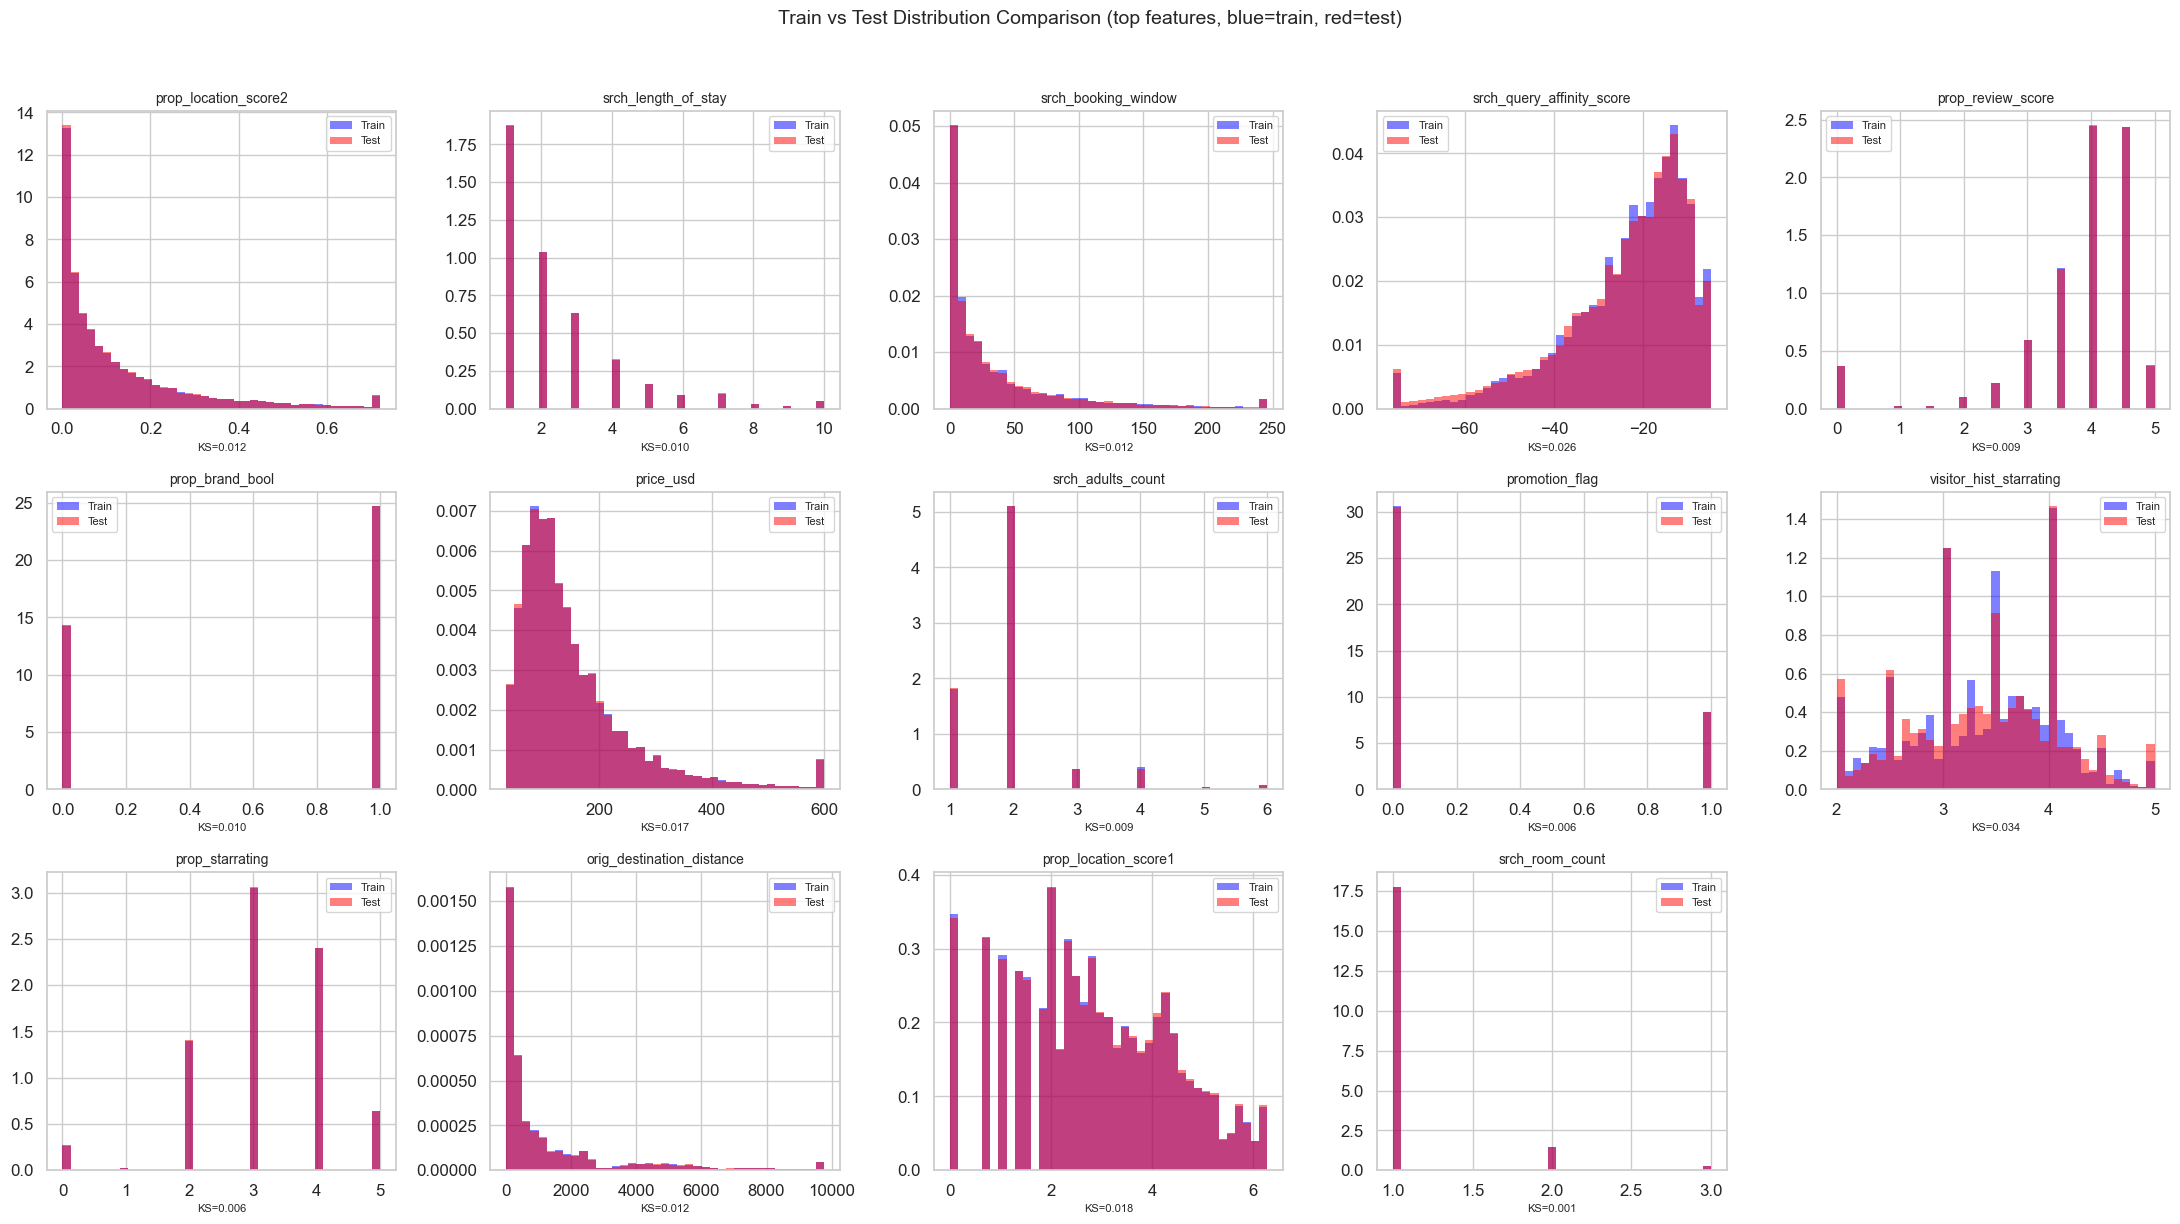

In [41]:
# Train vs Test distribution comparison
print("Loading test data...")
df_test = load_test()
print(f"Test shape: {df_test.shape}")

# Top 15 features from correlation analysis
top15_features = corr_df.head(15)["feature"].tolist()
# Filter to features that exist in both train and test
top15_features = [f for f in top15_features if f in df.columns and f in df_test.columns]
print(f"Comparing {len(top15_features)} features between train and test")

n_features = len(top15_features)
ncols = 5
nrows = (n_features + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(top15_features):
    ax = axes[i]
    
    train_vals = df[col].dropna()
    test_vals = df_test[col].dropna()
    
    if len(train_vals) == 0 or len(test_vals) == 0:
        ax.set_title(f"{col} (no data)")
        continue
    
    # Determine common range
    low = min(train_vals.quantile(0.01), test_vals.quantile(0.01))
    high = max(train_vals.quantile(0.99), test_vals.quantile(0.99))
    bins = np.linspace(low, high, 40)
    
    ax.hist(train_vals.clip(low, high), bins=bins, alpha=0.5, color="blue", 
            label="Train", density=True, edgecolor="none")
    ax.hist(test_vals.clip(low, high), bins=bins, alpha=0.5, color="red", 
            label="Test", density=True, edgecolor="none")
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
    
    # KS test for distribution shift
    ks_stat, ks_p = stats.ks_2samp(train_vals.sample(min(10000, len(train_vals)), random_state=42),
                                     test_vals.sample(min(10000, len(test_vals)), random_state=42))
    shift_flag = " *** SHIFT" if ks_stat > 0.1 else ""
    ax.set_xlabel(f"KS={ks_stat:.3f}{shift_flag}", fontsize=8)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Train vs Test Distribution Comparison (top features, blue=train, red=test)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3.11 Segmented Feature Importance

Different features may matter for different user/query segments. Compute feature-target correlations separately for key segments.

=== Spearman Correlation with booking_bool by Segment ===
                   price_usd  prop_starrating  prop_review_score  prop_location_score1  prop_location_score2  promotion_flag  prop_brand_bool  orig_destination_distance
All random           -0.0150           0.0096             0.0159               -0.0080                0.0367          0.0103           0.0150                    -0.0095
Domestic             -0.0154           0.0138             0.0131               -0.0073                0.0382          0.0120           0.0114                    -0.0041
International        -0.0115           0.0083             0.0204               -0.0048                0.0352          0.0107           0.0159                     0.0012
Short stay (1-2)     -0.0133           0.0146             0.0199               -0.0047                0.0460          0.0182           0.0137                     0.0070
Long stay (5+)       -0.0015           0.0127             0.0032               -0.0017           

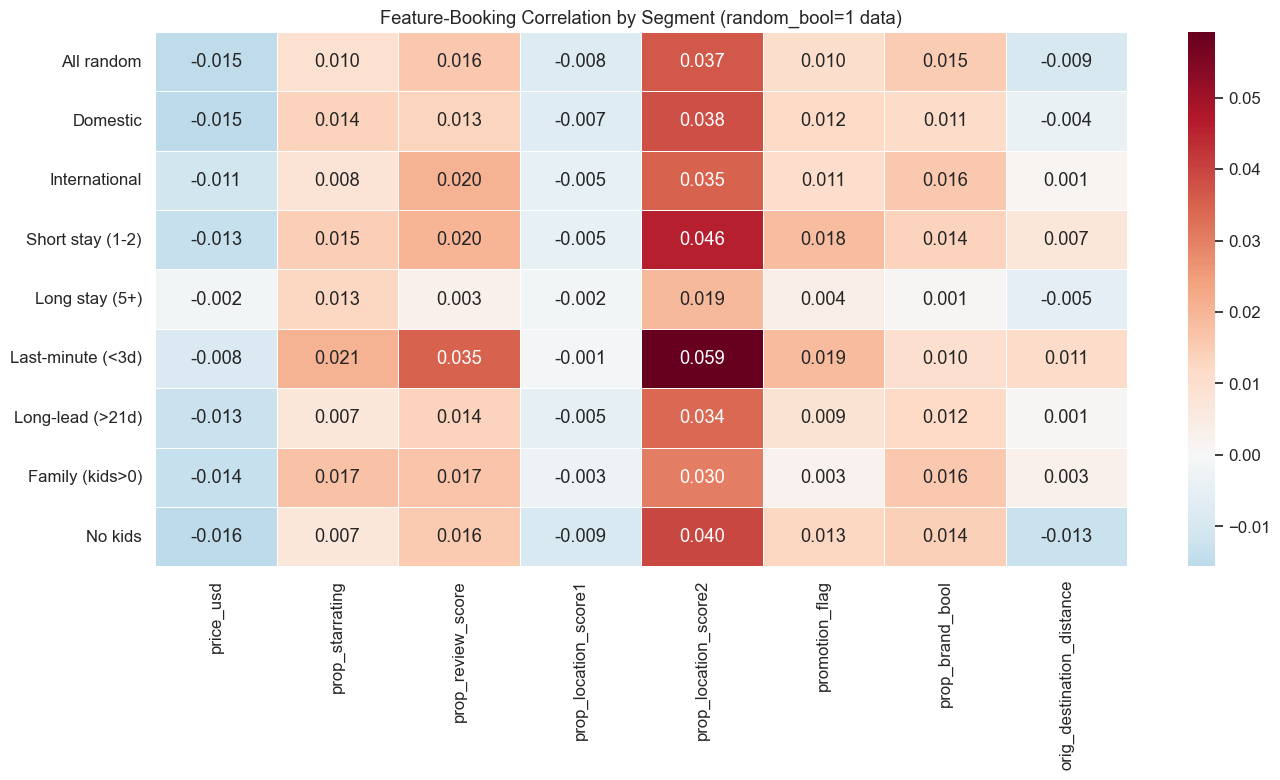

In [42]:
# Segmented feature-target correlations
# Use random_bool=1 subset for unbiased estimates
df_rand_seg = df[df["random_bool"] == 1].copy()

core_features = ["price_usd", "prop_starrating", "prop_review_score",
                 "prop_location_score1", "prop_location_score2",
                 "promotion_flag", "prop_brand_bool", "orig_destination_distance"]
core_features = [c for c in core_features if c in df_rand.columns]

segments = {
    "All random": df_rand,
    "Domestic": df_rand[df_rand["visitor_location_country_id"] == df_rand["prop_country_id"]],
    "International": df_rand[df_rand["visitor_location_country_id"] != df_rand["prop_country_id"]],
    "Short stay (1-2)": df_rand[df_rand["srch_length_of_stay"] <= 2],
    "Long stay (5+)": df_rand[df_rand["srch_length_of_stay"] >= 5],
    "Last-minute (<3d)": df_rand[df_rand["srch_booking_window"] < 3],
    "Long-lead (>21d)": df_rand[df_rand["srch_booking_window"] > 21],
    "Family (kids>0)": df_rand[df_rand["srch_children_count"] > 0],
    "No kids": df_rand[df_rand["srch_children_count"] == 0],
}

# Compute Spearman correlations with booking_bool
corr_matrix = {}
for seg_name, seg_df in segments.items():
    corrs = {}
    for feat in core_features:
        valid = seg_df[[feat, "booking_bool"]].dropna()
        if len(valid) > 100:
            rho, _ = stats.spearmanr(valid[feat], valid["booking_bool"])
            corrs[feat] = round(rho, 4)
        else:
            corrs[feat] = np.nan
    corr_matrix[seg_name] = corrs

corr_df = pd.DataFrame(corr_matrix).T
print("=== Spearman Correlation with booking_bool by Segment ===")
print(corr_df.to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(corr_df.astype(float), annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            ax=ax, linewidths=0.5)
ax.set_title("Feature-Booking Correlation by Segment (random_bool=1 data)")
plt.tight_layout()
plt.show()

## 3.12 Popularity Bias Analysis (Data Side)

Do frequent/popular hotels dominate bookings? This is relevant for the required bias analysis.

=== Booking & Click Rate by Property Popularity ===
            n_rows  click_rate  book_rate  n_unique_props
pop_bucket                                               
1-5         125481      0.0474     0.0277           57769
6-20        212816      0.0429     0.0274           20924
21-50       109824      0.0446     0.0278            3697
51-100       35772      0.0465     0.0289             541
100+         11160      0.0496     0.0283              72


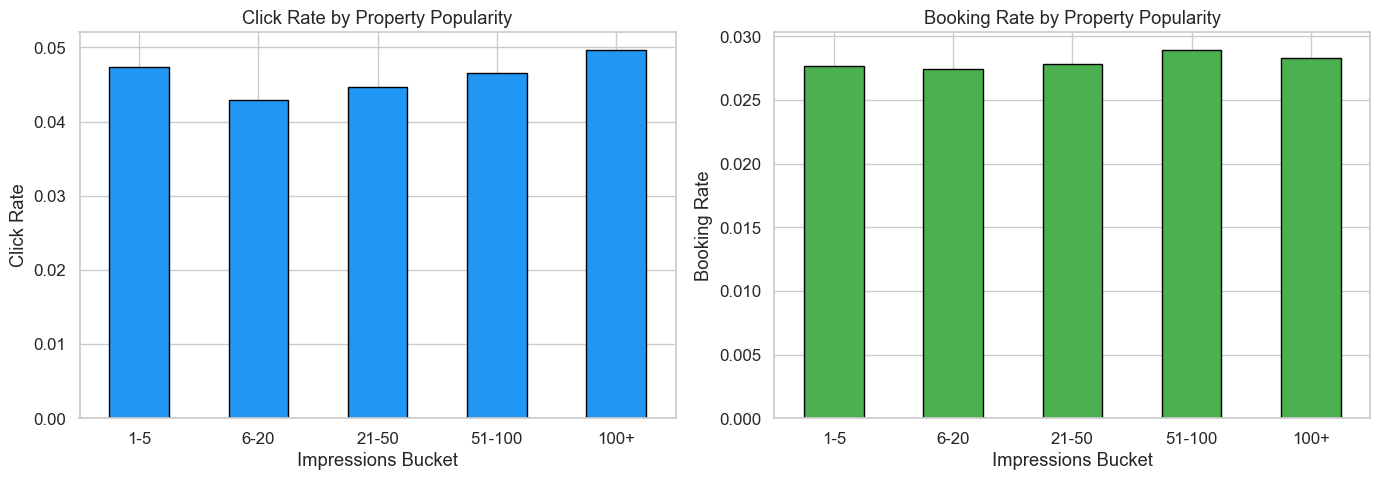

In [43]:
# Popularity bias: booking rate by property frequency
prop_counts = df.groupby("prop_id").size().reset_index(name="impressions")
df_pop = df.merge(prop_counts, on="prop_id", how="left")

# Create popularity buckets
bins = [0, 5, 20, 50, 100, float("inf")]
labels_pop = ["1-5", "6-20", "21-50", "51-100", "100+"]
df_pop["pop_bucket"] = pd.cut(df_pop["impressions"], bins=bins, labels=labels_pop)

pop_stats = df_pop.groupby("pop_bucket", observed=True).agg(
    n_rows=("click_bool", "size"),
    click_rate=("click_bool", "mean"),
    book_rate=("booking_bool", "mean"),
    n_unique_props=("prop_id", "nunique"),
).round(4)

print("=== Booking & Click Rate by Property Popularity ===")
print(pop_stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pop_stats["click_rate"].plot(kind="bar", ax=axes[0], color="#2196F3", edgecolor="black")
axes[0].set_title("Click Rate by Property Popularity")
axes[0].set_ylabel("Click Rate")
axes[0].set_xlabel("Impressions Bucket")
axes[0].tick_params(axis='x', rotation=0)

pop_stats["book_rate"].plot(kind="bar", ax=axes[1], color="#4CAF50", edgecolor="black")
axes[1].set_title("Booking Rate by Property Popularity")
axes[1].set_ylabel("Booking Rate")
axes[1].set_xlabel("Impressions Bucket")
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 3.13 Fairness & Bias Diagnosis (Data Side)

The assignment requires bias detection and mitigation. Here we identify representation and rate bias in the data. Model-side fairness metrics (NDCG by group) belong in Notebook 4.

In [44]:
# Fairness diagnosis: data-side bias
print("=== Fairness Dimensions — Data-Side Bias ===\n")

# 1. Family vs non-family
family = df[df["srch_children_count"] > 0]
no_family = df[df["srch_children_count"] == 0]
print(f"Family (children>0):  n={len(family):,}  click_rate={family['click_bool'].mean():.4f}  book_rate={family['booking_bool'].mean():.4f}")
print(f"No children:          n={len(no_family):,}  click_rate={no_family['click_bool'].mean():.4f}  book_rate={no_family['booking_bool'].mean():.4f}")

# 2. Domestic vs international
domestic = df[df["visitor_location_country_id"] == df["prop_country_id"]]
international = df[df["visitor_location_country_id"] != df["prop_country_id"]]
print(f"\nDomestic:       n={len(domestic):,}  click_rate={domestic['click_bool'].mean():.4f}  book_rate={domestic['booking_bool'].mean():.4f}")
print(f"International:  n={len(international):,}  click_rate={international['click_bool'].mean():.4f}  book_rate={international['booking_bool'].mean():.4f}")

# 3. Branded vs independent
branded = df[df["prop_brand_bool"] == 1]
independent = df[df["prop_brand_bool"] == 0]
print(f"\nBranded:      n={len(branded):,}  click_rate={branded['click_bool'].mean():.4f}  book_rate={branded['booking_bool'].mean():.4f}")
print(f"Independent:  n={len(independent):,}  click_rate={independent['click_bool'].mean():.4f}  book_rate={independent['booking_bool'].mean():.4f}")

# 4. Star rating tiers
low_star = df[df["prop_starrating"] <= 2]
high_star = df[df["prop_starrating"] >= 4]
print(f"\nLow-star (0-2):  n={len(low_star):,}  click_rate={low_star['click_bool'].mean():.4f}  book_rate={low_star['booking_bool'].mean():.4f}")
print(f"High-star (4-5): n={len(high_star):,}  click_rate={high_star['click_bool'].mean():.4f}  book_rate={high_star['booking_bool'].mean():.4f}")

print("\n=== Candidate bias dimensions for report Task 5 ===")
print("- Family vs non-family: do families get equivalent recommendation quality?")
print("- Domestic vs international: does model favor local travelers?")
print("- Branded vs independent: are independent hotels systematically disadvantaged?")
print("- Popular vs rare properties: cold-start bias")

=== Fairness Dimensions — Data-Side Bias ===



Family (children>0):  n=112,757  click_rate=0.0478  book_rate=0.0298
No children:          n=382,296  click_rate=0.0440  book_rate=0.0270

Domestic:       n=313,708  click_rate=0.0443  book_rate=0.0286
International:  n=181,345  click_rate=0.0458  book_rate=0.0262



Branded:      n=313,143  click_rate=0.0454  book_rate=0.0292


Independent:  n=181,910  click_rate=0.0439  book_rate=0.0251

Low-star (0-2):  n=107,786  click_rate=0.0328  book_rate=0.0202
High-star (4-5): n=193,299  click_rate=0.0520  book_rate=0.0311

=== Candidate bias dimensions for report Task 5 ===
- Family vs non-family: do families get equivalent recommendation quality?
- Domestic vs international: does model favor local travelers?
- Branded vs independent: are independent hotels systematically disadvantaged?
- Popular vs rare properties: cold-start bias


## 3.14 Competitor Feature Reliability

Check whether competitor data availability is biased — if it only exists for popular hotels, comp_rate_count may proxy for popularity.

In [45]:
# Competitor availability by segment
comp_cols = [f"comp{i}_rate" for i in range(1, 9) if f"comp{i}_rate" in df.columns]
df_comp = df.copy()
df_comp["n_comp_available"] = df_comp[comp_cols].notna().sum(axis=1)

# By brand
brand_comp = df_comp.groupby("prop_brand_bool")["n_comp_available"].mean()
print("=== Competitor Availability by Brand ===")
print(f"  Independent (0): {brand_comp.get(0, 0):.2f} competitors available on avg")
print(f"  Branded (1):     {brand_comp.get(1, 0):.2f} competitors available on avg")

# By star rating
star_comp = df_comp.groupby("prop_starrating")["n_comp_available"].mean()
print("\n=== Competitor Availability by Star Rating ===")
for star, avg in star_comp.items():
    print(f"  {star}-star: {avg:.2f} competitors available on avg")

# By site
site_comp = df_comp.groupby("site_id")["n_comp_available"].mean().sort_values(ascending=False)
print("\n=== Competitor Availability by Site (top 10) ===")
for site, avg in site_comp.head(10).items():
    print(f"  site {site}: {avg:.2f}")

# By price tier
df_comp["price_tier"] = pd.qcut(df_comp["price_usd"], q=4, labels=["Cheap", "Mid-low", "Mid-high", "Expensive"])
tier_comp = df_comp.groupby("price_tier", observed=True)["n_comp_available"].mean()
print("\n=== Competitor Availability by Price Tier ===")
for tier, avg in tier_comp.items():
    print(f"  {tier}: {avg:.2f}")

=== Competitor Availability by Brand ===
  Independent (0): 1.33 competitors available on avg
  Branded (1):     1.98 competitors available on avg

=== Competitor Availability by Star Rating ===
  0-star: 0.57 competitors available on avg
  1-star: 0.88 competitors available on avg
  2-star: 1.73 competitors available on avg
  3-star: 1.67 competitors available on avg
  4-star: 1.92 competitors available on avg
  5-star: 2.01 competitors available on avg



=== Competitor Availability by Site (top 10) ===
  site 6: 2.22
  site 26: 2.05
  site 17: 1.92
  site 5: 1.90
  site 7: 1.85
  site 22: 1.81
  site 31: 1.79
  site 14: 1.77
  site 2: 1.73
  site 13: 1.71

=== Competitor Availability by Price Tier ===
  Cheap: 1.66
  Mid-low: 1.72
  Mid-high: 1.75
  Expensive: 1.85


## 3.15 Sanity-Check Baseline Rankings

Compare simple rule-based rankings to contextualize ML model performance. Each ranks hotels within a query by a single feature.

In [46]:
from src.data_loader import split_val
from src.evaluate import evaluate_ndcg

# Baseline rankings — simple rule-based approaches
from src.data_loader import split_val, make_target
from src.evaluate import evaluate_ndcg

# Use the full 10% sample with targets
df_bl = df.copy()
_, val_bl = split_val(df_bl, val_frac=0.1)
val_bl = val_bl.sort_values("srch_id").reset_index(drop=True)

baselines = {
    "Cheapest first": ("price_usd", True),
    "Highest stars": ("prop_starrating", False),
    "Highest review": ("prop_review_score", False),
    "Best location1": ("prop_location_score1", False),
    "Promotion first": ("promotion_flag", False),
}

# Value score
val_bl["value_score"] = val_bl["prop_starrating"] / np.log1p(val_bl["price_usd"])
baselines["Best value (star/log_price)"] = ("value_score", False)

# Expedia position (non-random only)
val_nonrand = val_bl[val_bl["random_bool"] == 0].copy()
if "position" in val_nonrand.columns and len(val_nonrand) > 0:
    val_nonrand["neg_position"] = -val_nonrand["position"]
    ndcg_pos = evaluate_ndcg(val_nonrand, score_col="neg_position", k=5)
else:
    ndcg_pos = None

print("=== Baseline Rankings — NDCG@5 on Validation ===")
print(f"{'Method':<35} {'NDCG@5':>10}")
print("-" * 48)

for name, (col, ascending) in baselines.items():
    if col in val_bl.columns:
        val_bl["_score"] = val_bl[col] * (-1 if ascending else 1)
        val_bl["_score"] = val_bl["_score"].fillna(val_bl["_score"].min() - 1)
        ndcg = evaluate_ndcg(val_bl, score_col="_score", k=5)
        print(f"{name:<35} {ndcg:>10.4f}")

if ndcg_pos is not None:
    print(f"{'Expedia position (non-random)':<35} {ndcg_pos:>10.4f}")

print(f"\n{'V3 LambdaRank model':<35} {'0.4170':>10}")
print("\nContext: the ML model should significantly outperform all single-feature baselines.")

=== Baseline Rankings — NDCG@5 on Validation ===
Method                                  NDCG@5
------------------------------------------------


Cheapest first                          0.2049


Highest stars                           0.1918


Highest review                          0.1610


Best location1                          0.1769


Promotion first                         0.2004


Best value (star/log_price)             0.2486
Expedia position (non-random)           0.3967

V3 LambdaRank model                     0.4170

Context: the ML model should significantly outperform all single-feature baselines.


from src.data_loader import split_val
from src.evaluate import evaluate_ndcg

### Key Findings - New Sections (3.11-3.15)

- **Segmented correlations**: Feature importance varies across segments. Features that matter for last-minute bookers may differ from long-lead travelers.
- **Popularity bias**: Popular hotels may have higher booking rates partly due to more data/better aggregate features, not intrinsic quality.
- **Fairness dimensions**: Family, domestic/international, branded/independent, and star-tier disparities are candidates for the required bias analysis.
- **Competitor reliability**: If competitor data is more available for certain hotel types, comp features partially proxy for hotel characteristics.
- **Baseline rankings**: Single-feature rankings provide a performance floor. The ML model should clearly beat all of them.

## Final Summary

### Most Important Features for Ranking (from within-query analysis)

The LambdaRank model ranks hotels **within each query**. Only features that vary across hotels in the same search provide direct ranking signal:

1. **prop_location_score1 / score2** -- strongest positive correlators with booking within queries
2. **price_usd** -- primary negative correlator (cheaper = more booked); **price_rank_in_query** amplifies this
3. **prop_starrating / prop_review_score** -- quality signals that vary across hotels
4. **prop_brand_bool** -- branded hotels get a lift
5. **Competitor aggregates** (n_comp_expensive, mean_comp_pct_diff) -- competitive positioning
6. **prop_log_historical_price** -- price anchoring effect

### Feature Engineering Priorities

**High priority (implement first):**
- `price_rank_in_query`, `price_z_score_in_query` -- within-query price normalization
- `value_score = starrating / log1p(price)` -- quality-per-dollar
- `star_diff` and `price_ratio` -- visitor history matching
- `n_comp_expensive`, `n_comp_cheaper`, `n_comp_no_inv` -- competitor aggregation
- `price_per_night` -- normalize for length of stay

**Medium priority:**
- `is_domestic`, `has_location_score2`, `has_historical_price`, `has_visitor_history` -- informative binary flags
- `log_distance`, `star_review_product`, `price_per_person` -- non-linear transformations and interactions
- `mean_comp_pct_diff` -- continuous competitive advantage measure

**Low priority (nice to have):**
- Booking window segment interactions
- Promotion x price quintile interaction

### Key Modeling Insights

- **Tier 2 features** (search parameters) are constant within a query. They don't rank hotels directly but provide context. Tree-based models can learn interactions implicitly, but explicit features help.
- **Missing values are informative** -- missingness in location_score2, distance, visitor history, and competitors all correlate with booking rates. Use missing indicators.
- **Train-test distributions** are generally well-aligned. Features with KS > 0.1 should be monitored for domain shift.
- **Use random_bool=1 data** for any feature importance analysis to avoid position bias contamination.